In [1]:
from itertools import product
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pytz
import os
from glob import glob
from itertools import combinations,chain
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import summary_table

In [2]:
watersheds=["anacostia","don","ipswich","miami","chicago","socal","sfbay"]
ws_names={"anacostia":"Anacostia","don":"Don","ipswich":"Ipswich","miami":"Miami","chicago":"N.Chicago","socal":"S.California","sfbay":"Walnut"}


In [3]:
root="/mnt/c/Users/soggy/OneDrive - USNH/Dox/PSIREN/ocBottleTracker/" # Change to user directory
fldr=root+"supportingData/"
distances = pd.read_csv(fldr+f"allsites_bottleTracker_Movement_Summary_NHD.txt",sep="\t",index_col=[0,1,2],parse_dates=True)

/tmp/ipykernel_4415/3563730602.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  distances = pd.read_csv(fldr+f"allsites_bottleTracker_Movement_Summary_NHD.txt",sep="\t",index_col=[0,1,2],parse_dates=True)
/tmp/ipykernel_4415/3563730602.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  distances = pd.read_csv(fldr+f"allsites_bottleTracker_Movement_Summary_NHD.txt",sep="\t",index_col=[0,1,2],parse_dates=True)


In [4]:
distances.index.names = "watershed Asset dt".split()

In [5]:
print ( (distances['len_m'] > 10000.).sum() )
print( (distances['len_m'] > 1000.).sum() )
print( (distances['len_m'] > 0.).sum() )

9
222
1288


In [6]:
distances

site_no  \
watershed Asset              dt                                    
chicago   Clyde              2022-09-12 10:57:43-05:00  05535000   
                             2022-10-11 05:02:01-05:00  05535000   
                             2022-10-30 11:11:29-05:00  05535000   
          Caleb              2022-11-17 04:10:10-06:00  05535000   
          Cassidy            2022-09-15 23:01:51-05:00  05535000   
...                                                          ...   
socal     Periwinkle_1_1     2024-02-05 06:00:50-08:00  11048600   
                             2024-02-07 09:58:50-08:00  11048600   
                             2024-02-08 09:51:31-08:00  11048600   
                             2024-02-09 13:58:32-08:00  11048600   
          Skip Jack Tuna_1_1 2024-02-05 11:04:20-08:00  11048600   

                                                               len_m  \
watershed Asset              dt                                        
chicago   Clyde              2022-09-12 10:57:43-05:00    912.820429   
                             2022-10-11 05:02:01-05:00      7.874707   
                             2022-10-30 11:11:29-05:00      5.114577   
          Caleb              2022-11-17 04:10:10-06:00     10.168867   
          Cassidy            2022-09-15 23:01:51-05:00      5.126566   
...                                                              ...   
socal     Periwinkle_1_1     2024-02-05 06:00:50-08:00   2797.258326   
                             2024-02-07 09:58:50-08:00     52.850129   
                             2024-02-08 09:51:31-08:00     38.190741   
                             2024-02-09 13:58:32-08:00     36.696395   
          Skip Jack Tuna_1_1 2024-02-05 11:04:20-08:00  12908.641794   

                                                               lon        lat  \
watershed Asset              dt                                                 
chicago   Clyde              2022-09-12 10:57:43-05:00  -87.854285  42.249377   
                             2022-10-11 05:02:01-05:00  -87.854273  42.249353   
                             2022-10-30 11:11:29-05:00  -87.854307  42.249419   
          Caleb              2022-11-17 04:10:10-06:00  -87.857014  42.259590   
          Cassidy            2022-09-15 23:01:51-05:00  -87.854373  42.249547   
...                                                            ...        ...   
socal     Periwinkle_1_1     2024-02-05 06:00:50-08:00 -117.868275  33.650383   
                             2024-02-07 09:58:50-08:00 -117.877723  33.648525   
                             2024-02-08 09:51:31-08:00 -117.877786  33.648529   
                             2024-02-09 13:58:32-08:00 -117.878522  33.648575   
          Skip Jack Tuna_1_1 2024-02-05 11:04:20-08:00 -117.902756  33.619086   

                                                        totdasqkm  sinuosity  \
watershed Asset              dt                                                
chicago   Clyde              2022-09-12 10:57:43-05:00    26.1928   0.789986   
                             2022-10-11 05:02:01-05:00    26.1928   0.789986   
                             2022-10-30 11:11:29-05:00    26.1928   0.789986   
          Caleb              2022-11-17 04:10:10-06:00    26.1928   0.789986   
          Cassidy            2022-09-15 23:01:51-05:00    26.1928   0.789986   
...                                                           ...        ...   
socal     Periwinkle_1_1     2024-02-05 06:00:50-08:00   275.4389   1.027011   
                             2024-02-07 09:58:50-08:00   275.4389   1.027011   
                             2024-02-08 09:51:31-08:00   275.4389   1.027011   
                             2024-02-09 13:58:32-08:00   275.4389   1.027011   
          Skip Jack Tuna_1_1 2024-02-05 11:04:20-08:00 -9999.0000   3.254901   

                                                        slope10m  u_slope10m  \
watershed Asset              dt                             

Now a bunch of watershed properties are calculated using networkTools on UNH Servers, tabulated, saved to the "lc" subdirectory, and are joined here.

In [7]:
lcs={"21":"Developed (Open)","22":"Developed (Low)","23":"Developed (Med.)","24":"Developed (High)","22_23_24":"Developed (Sum)",
     "31": "Barren","41": "Decid. Forest", "42": "Evergreen Forest", "43": "Mixed Forest", "41_42_43": "Forest", 
     "52": "Shrub/Scrub", "71": "Grassland" ,"81": "Pasture","82": "Row Crops","90": "Woody Wetlands", "95": "Herbaceous Wetlands"}
LCs=dict([(k,{}) for k in ws_names.keys() ])
for ws,lc in product(ws_names.keys(),lcs.keys()):
    L=pd.read_csv(fldr+'lc/{}_extract_{}.csv'.format(ws,lc),sep="\t",index_col="Site_ID")
    LCs[ws][lc]=L
    

In [8]:
lcs={"21":"Developed (Open)","22":"Developed (Low)","23":"Developed (Med.)","24":"Developed (High)","22_23_24":"Developed (Sum)",
     "31": "Barren","41": "Decid. Forest", "42": "Evergreen Forest", "43": "Mixed Forest", "41_42_43": "Forest", 
     "52": "Shrub/Scrub", "71": "Grassland" ,"81": "Pasture","82": "Row Crops","90": "Woody Wetlands", "95": "Herbaceous Wetlands"}

In [9]:
LC=pd.concat(dict([(k,pd.concat(LCs[k])) for k in LCs.keys()]))
LC=LC.xs("Data",axis=1).unstack(level=1).reset_index(level=0)
LC.index = LC.index.rename("Point_ID")
lcdistances=distances.join(LC,on="Point_ID")

In [10]:
# Filling in Don's land-cover from Schwenk et al. 2025
psiren_2_trca_sites={"PR":"HY019","YM":"HY022","TC":"HY062","GM":"HY113"}
don_lc={"HY019":{"22_23_24":80.66, "31":1.73, "41_42_43":9.57, "90":0.4, "82":4.6, "52":2.83},
 "HY062":{"22_23_24":90.71,"31":1.1,"41_42_43":5.3,"90":0.22, "82":0.42,"52":2.25},
 "HY022":{"22_23_24":77.32, "31":1.81, "41_42_43":11.23, "90":0.45,"82":6.01, "52":3.01},
 "HY113": {"22_23_24":85.71,"31":1.08, "41_42_43":5.59, "90":0.63, "82":3.98,"52":3.0}
}
don_lc=pd.DataFrame.from_dict(don_lc,orient="index")
# Invent naive estimates for other landcover classes
for lc in "22 23 24".split():
    don_lc[lc]=don_lc["22_23_24"]/4.
don_lc['21']=don_lc["22_23_24"]/4.
for lc in "41 42 43".split():
    don_lc[lc]=don_lc["41_42_43"]/3.
don_lc["71"]=0.
don_lc['81']=0.
don_lc['95']=0.

In [11]:
for site,row in don_lc.iterrows():
    for col,val in row.items():
        print(site,col,val)
        lcdistances.loc[lcdistances["site_no"]==site,col] = val
    

HY019 22_23_24 80.66
HY019 31 1.73
HY019 41_42_43 9.57
HY019 90 0.4
HY019 82 4.6
HY019 52 2.83
HY019 22 20.165
HY019 23 20.165
HY019 24 20.165
HY019 21 20.165
HY019 41 3.19
HY019 42 3.19
HY019 43 3.19
HY019 71 0.0
HY019 81 0.0
HY019 95 0.0
HY062 22_23_24 90.71
HY062 31 1.1
HY062 41_42_43 5.3
HY062 90 0.22
HY062 82 0.42
HY062 52 2.25
HY062 22 22.6775
HY062 23 22.6775
HY062 24 22.6775
HY062 21 22.6775
HY062 41 1.7666666666666666
HY062 42 1.7666666666666666
HY062 43 1.7666666666666666
HY062 71 0.0
HY062 81 0.0
HY062 95 0.0
HY022 22_23_24 77.32
HY022 31 1.81
HY022 41_42_43 11.23
HY022 90 0.45
HY022 82 6.01
HY022 52 3.01
HY022 22 19.33
HY022 23 19.33
HY022 24 19.33
HY022 21 19.33
HY022 41 3.7433333333333336
HY022 42 3.7433333333333336
HY022 43 3.7433333333333336
HY022 71 0.0
HY022 81 0.0
HY022 95 0.0
HY113 22_23_24 85.71
HY113 31 1.08
HY113 41_42_43 5.59
HY113 90 0.63
HY113 82 3.98
HY113 52 3.0
HY113 22 21.4275
HY113 23 21.4275
HY113 24 21.4275
HY113 21 21.4275
HY113 41 1.8633333333333333
H

In [12]:
lcdistances.loc[lcdistances["totdasqkm"]<0,'totdasqkm']=np.nan
lcdistances.loc[lcdistances['Q_m3s']<0,'Q_m3s']=np.nan
lcdistances.loc[lcdistances['slope_mean']<0,'slope_mean']=np.nan
lcdistances.loc[lcdistances['slope10m'] <0,'slope10m']=np.nan
lcdistances.loc[lcdistances['u_slope10m'] <0,'u_slope10m']=np.nan
lcdistances.loc[lcdistances['sinuosity']<1,'sinuosity']=1.001

In [13]:
lcdistclean=lcdistances.dropna()

WE have a lot of potential descriptors of our travel distances.  There is a forest of potential models we could create.  Use Gradient Boosted Trees to try to evaluate the importance of models.

We want to start looking into the possibility of using multiple indicator variables to describe what's happening. 

In [14]:
lcs["Q_m3s"] = r"Q ($m^3\ s^{-1}$)"
lcs["u_slope10m"] = "slope10m.std"

Index(['len_m', 'lon', 'lat', 'totdasqkm', 'sinuosity', 'slope10m',
       'u_slope10m', 'slope_mean', 'slope_std', '00060', 'tt_days', 'Q_m3s',
       'omega0', 'Q2h', 'Q4h', 'Q12h', 'Q24h', '21', '22', '23', '24',
       '22_23_24', '31', '41', '42', '43', '41_42_43', '52', '71', '81', '82',
       '90', '95'],
      dtype='object')
The r2 on the test set: 0.4099
The mse on the test set: 2.9192


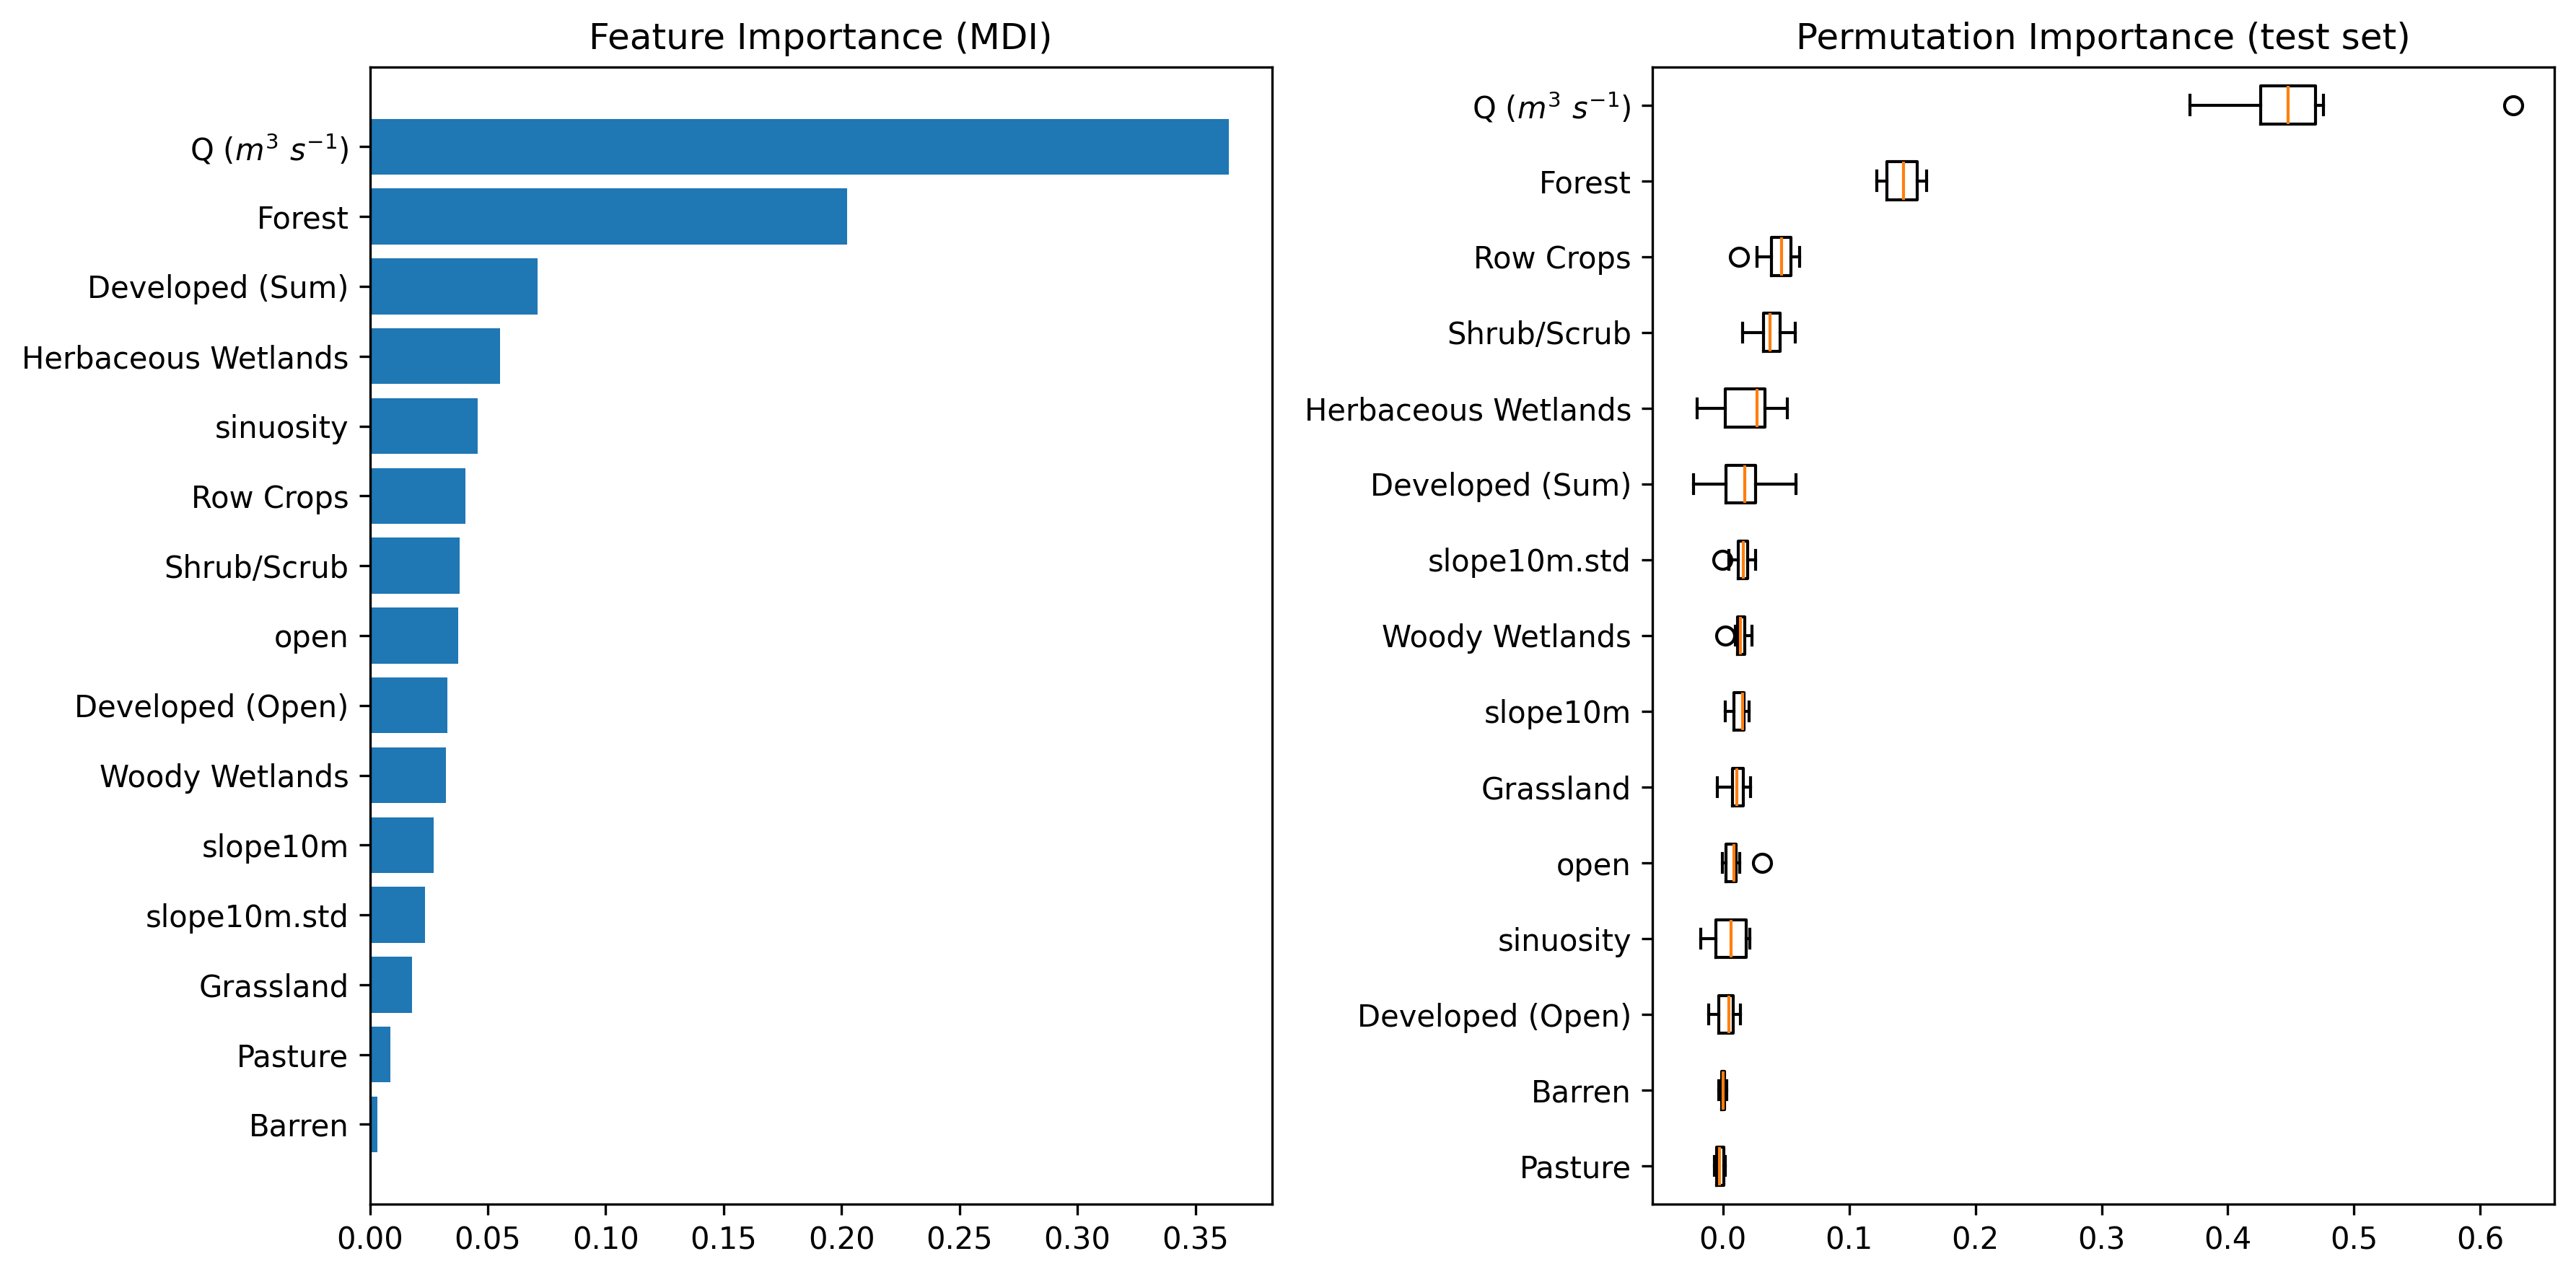

In [15]:
import shap
from sklearn import ensemble
import sklearn.metrics as skmetrics
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.utils.fixes import parse_version
temp = lcdistclean.set_index("site_no",append=True).drop(columns=['Point_ID','level_0'])
print(temp.columns)
temp["sinuosity"] = temp['sinuosity'].clip(lower=1.00001)
temp["open"] = temp["41_42_43"]+temp["52"]+temp["21"]+temp["71"]+temp["81"]
temp = temp.dropna()
temp["omega0"]=temp['omega0'].astype(float)
y=temp["len_m"].values

drop_cols = ['Q2h', 'Q4h','Q12h', 'Q24h','00060','lon','lat','tt_days','omega0','slope_std','slope_mean','totdasqkm','22','23','24','41','42','43']
temp = temp.drop(columns=drop_cols)


X=temp[[x for x in temp.columns if x != "len_m"]]
names=X.columns
#X=X.values
X = np.log(X.clip(lower=1e-7))
y = np.log(y)
X_train,X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=3)
params = {"n_estimators":50, "max_depth":5,"min_samples_split":3,"learning_rate":0.1,"loss":"huber",'random_state':116}
reg = ensemble.GradientBoostingRegressor(**params)
reg.fit(X_train,y_train)
r2 = skmetrics.r2_score(y_test,reg.predict(X_test))
print("The r2 on the test set: {:0.4f}".format(r2))
mse = skmetrics.mean_squared_error(y_test,reg.predict(X_test))
print("The mse on the test set: {:0.4f}".format(mse))
feature_importance = reg.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5
fig = plt.figure(figsize=(12, 6),dpi=300)
plt.subplot(1, 2, 1)
plt.barh(pos, feature_importance[sorted_idx], align="center")
plt.yticks(pos, [lcs[x] if x in lcs.keys() else x for x in X.columns[sorted_idx]]) # X.columns[sorted_idx]) #
plt.title("Feature Importance (MDI)")

result = permutation_importance(
    reg, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)
sorted_idx = result.importances_mean.argsort()
plt.subplot(1, 2, 2)

# `labels` argument in boxplot is deprecated in matplotlib 3.9 and has been
# renamed to `tick_labels`. The following code handles this, but as a
# scikit-learn user you probably can write simpler code by using `labels=...`
# (matplotlib < 3.9) or `tick_labels=...` (matplotlib >= 3.9).
tick_labels_parameter_name = (
    "tick_labels"
    if parse_version(mpl.__version__) >= parse_version("3.9")
    else "labels"
)
tick_labels_dict = {
    tick_labels_parameter_name: [lcs[x] if x in lcs.keys() else x for x in X.columns[sorted_idx]]
}
plt.boxplot(result.importances[sorted_idx].T, vert=False, **tick_labels_dict)
plt.title("Permutation Importance (test set)")
fig.tight_layout()
plt.show()

PermutationExplainer explainer: 250it [00:30,  7.75it/s]                                                                
/tmp/ipykernel_4415/1676048455.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test,feature_names=[lcs[x] if x in lcs.keys() else x for x in X])


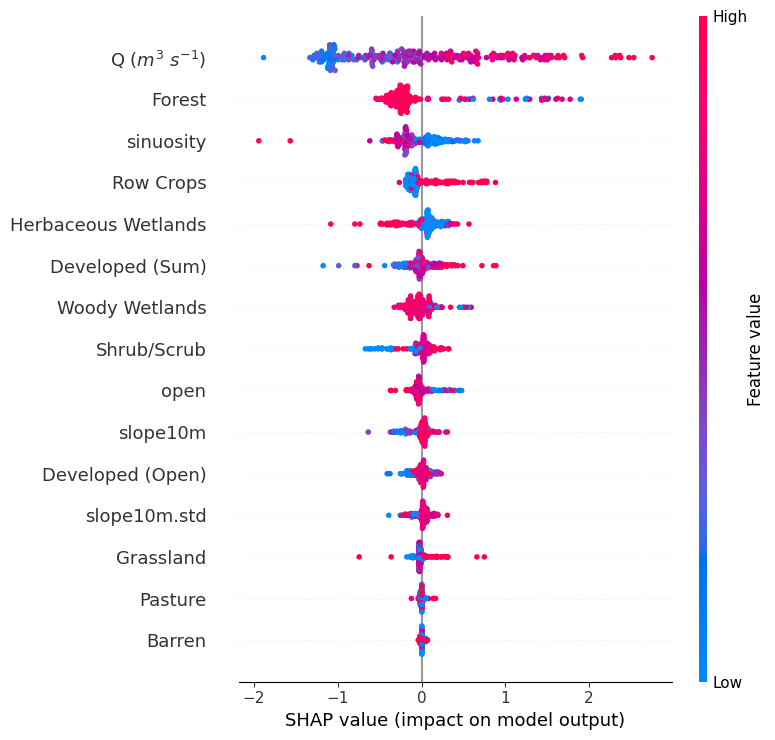

<Figure size 3000x1800 with 0 Axes>

In [16]:
fig,ax=plt.subplots(1,1)
# Create SHAP explainer
explainer = shap.Explainer(reg.predict, X_train,seed=506)

# Calculate SHAP values
shap_values = explainer(X_test)

# Plot summary
shap.summary_plot(shap_values, X_test,feature_names=[lcs[x] if x in lcs.keys() else x for x in X])
fig=plt.gcf()
fig.set_dpi(600)
fig.set_size_inches((5,3))

Q_m3s


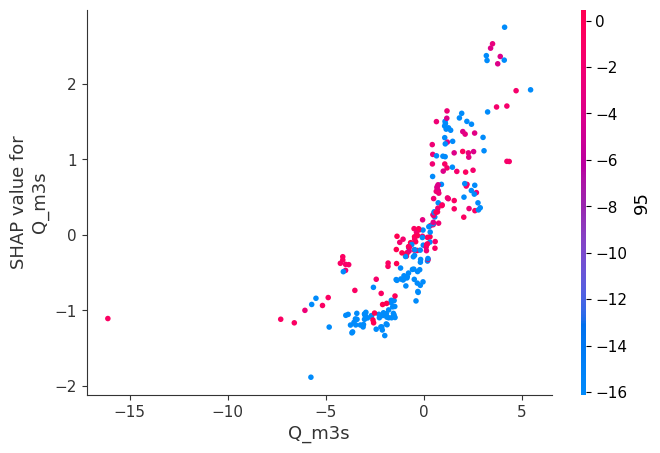

41_42_43


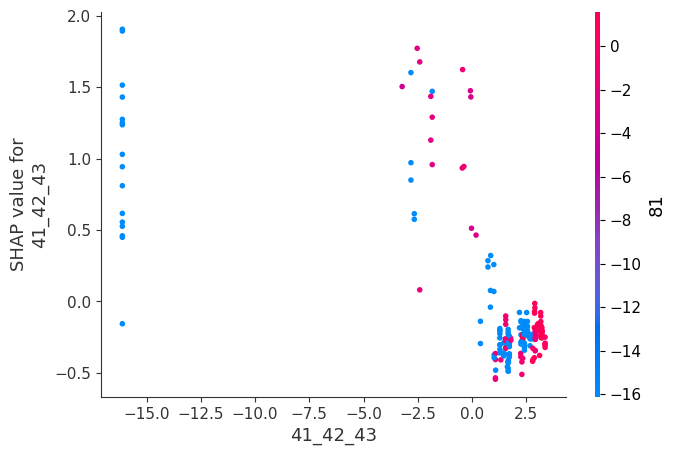

sinuosity


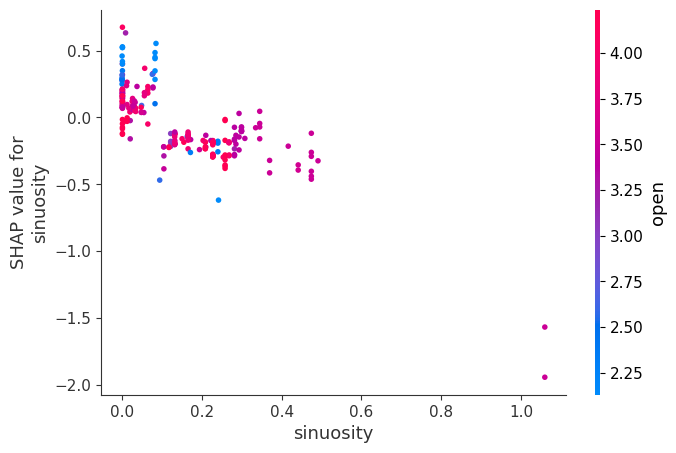

95


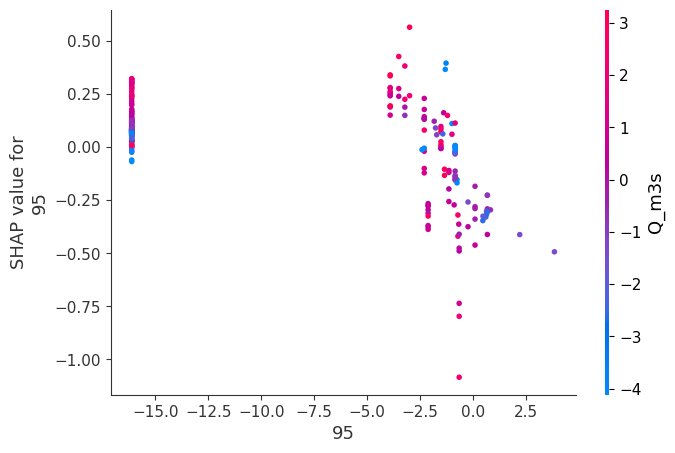

22_23_24


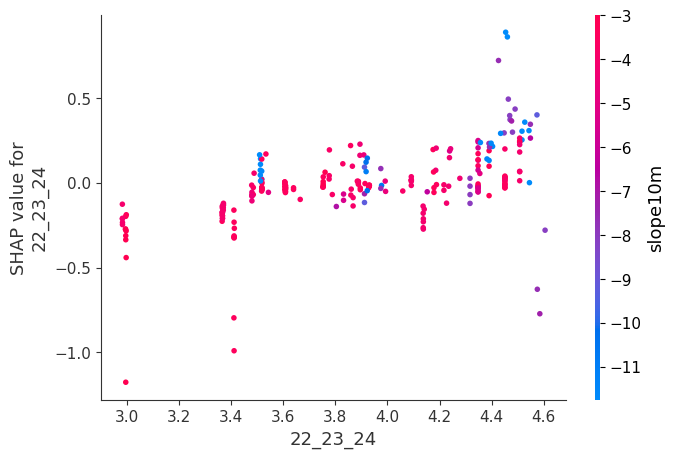

82


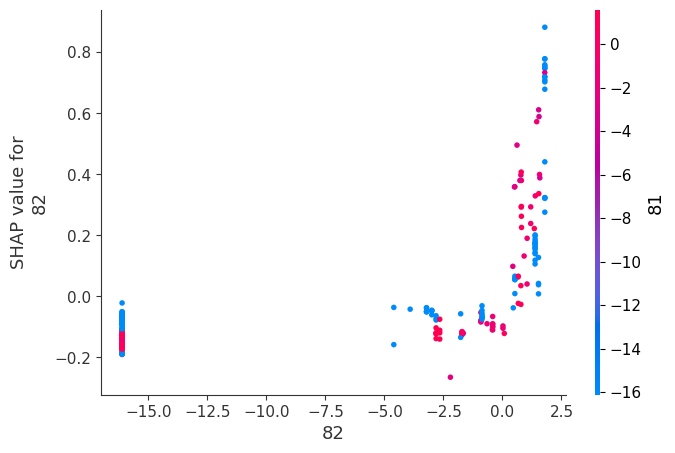

In [17]:
# Dependence plots

for feature in ["Q_m3s", "41_42_43", "sinuosity", "95", "22_23_24", "82"]:
    print(feature)
    shap.dependence_plot(feature, shap_values.values, X_test)


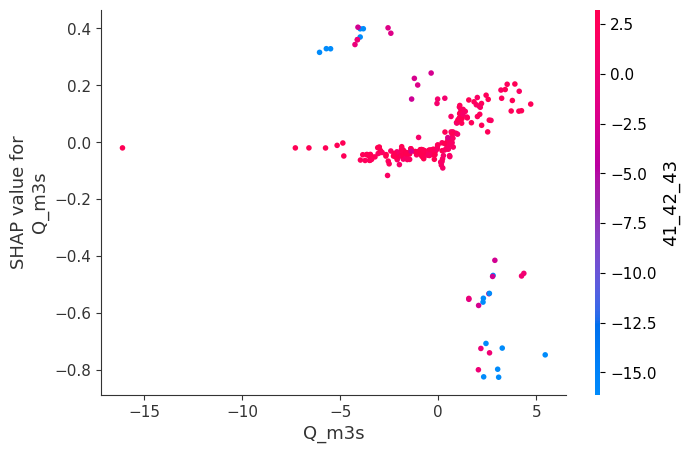

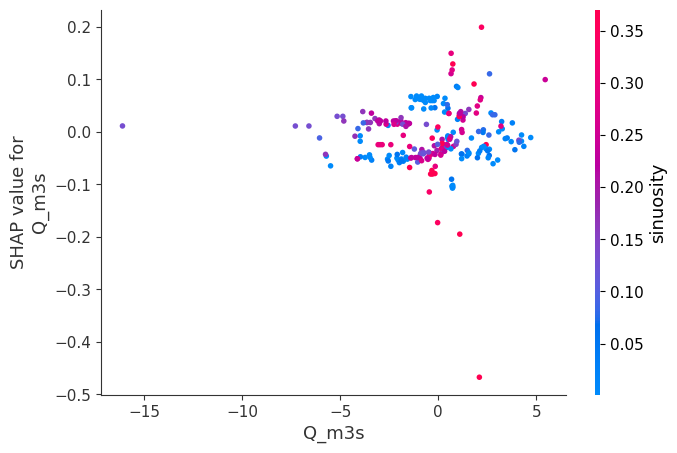

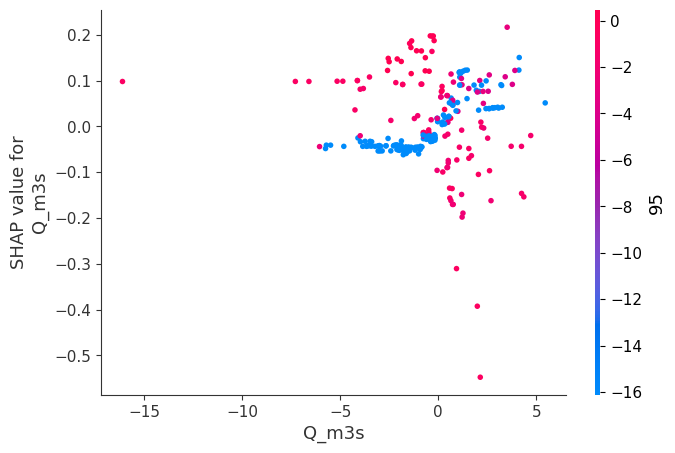

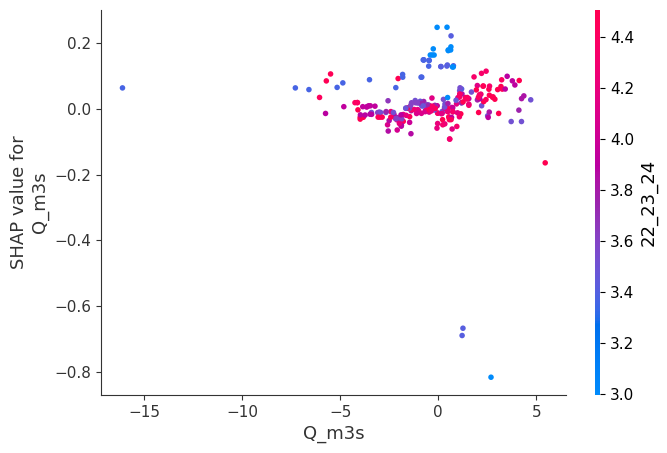

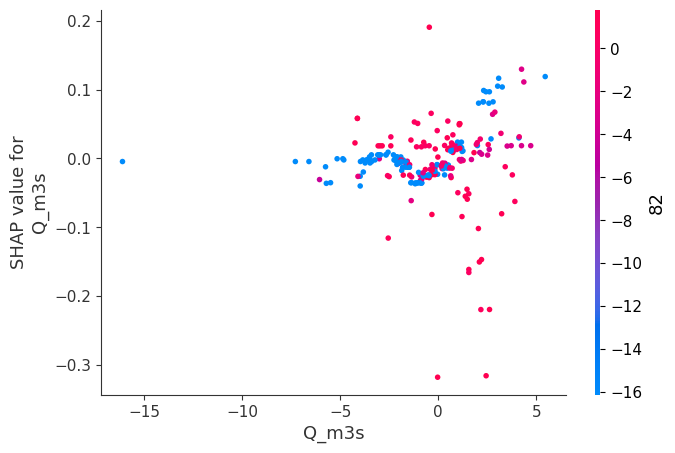

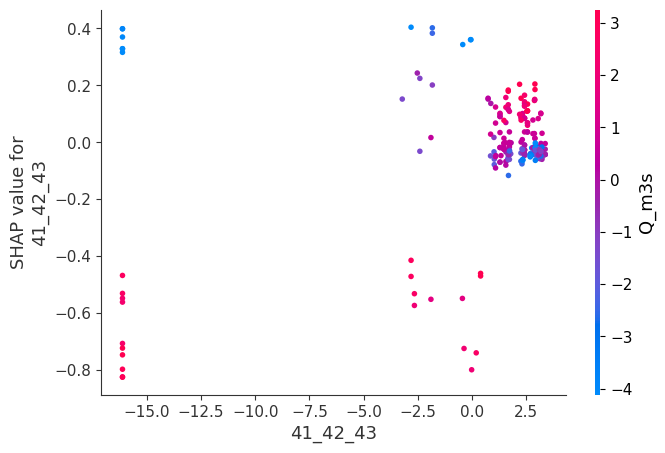

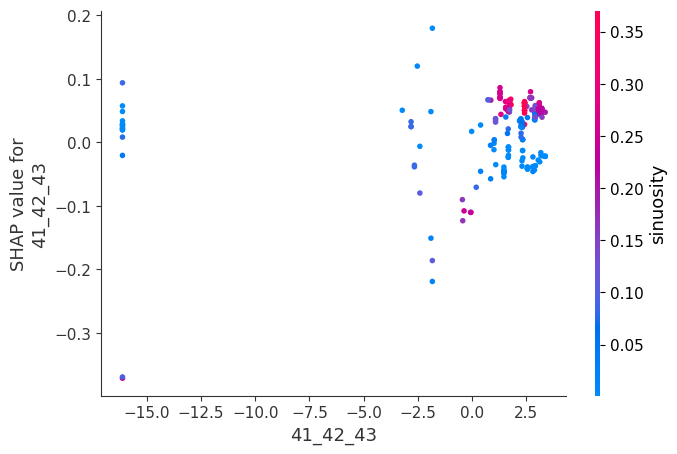

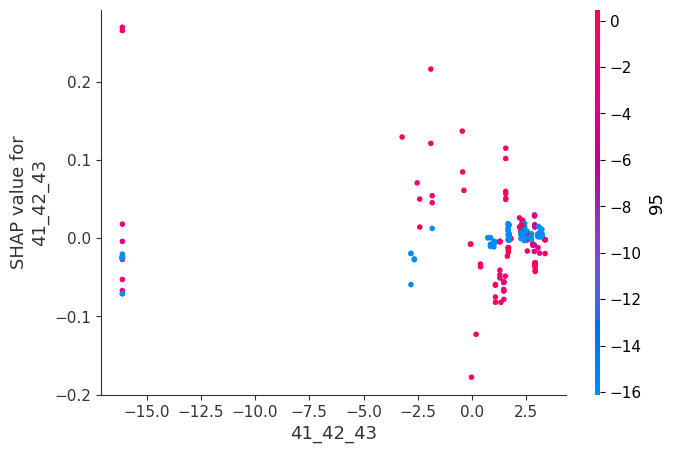

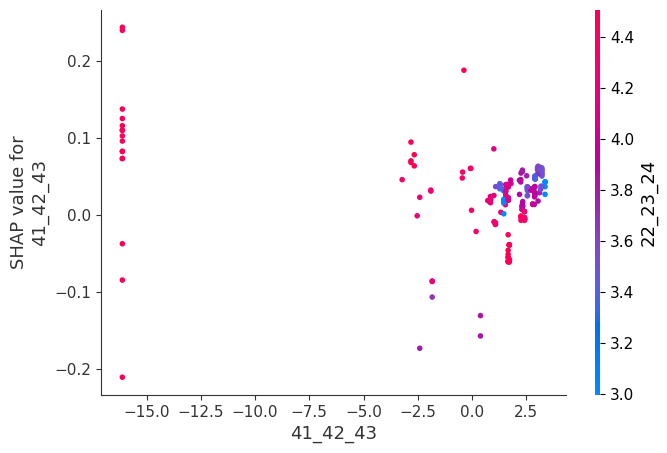

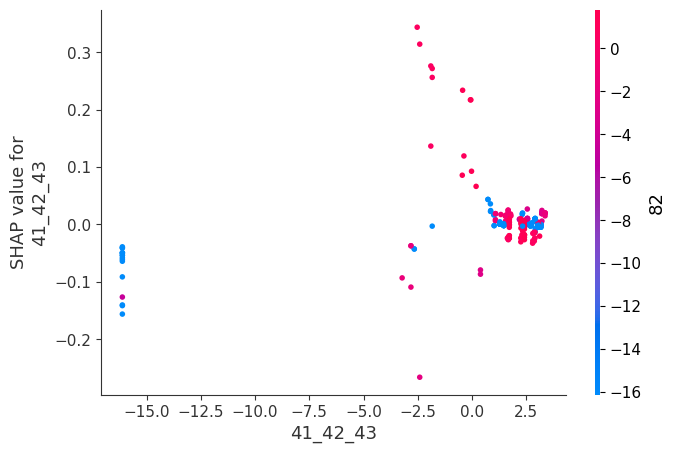

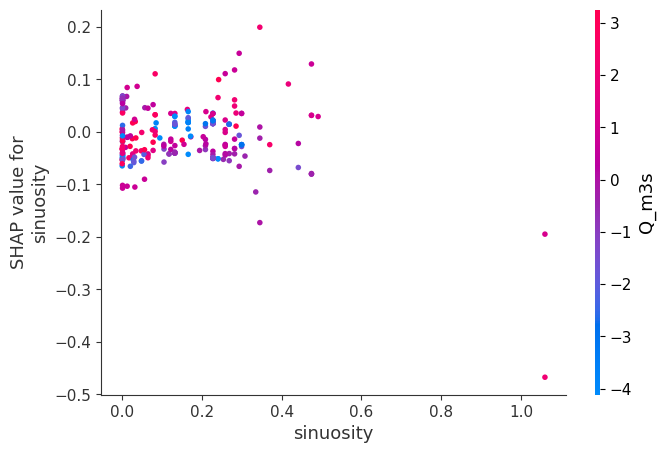

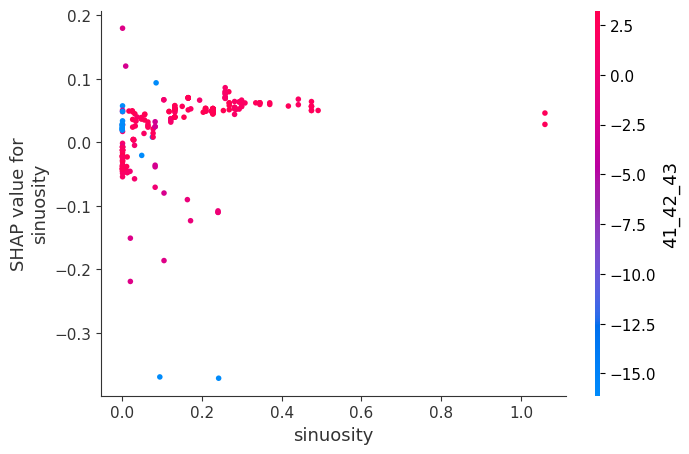

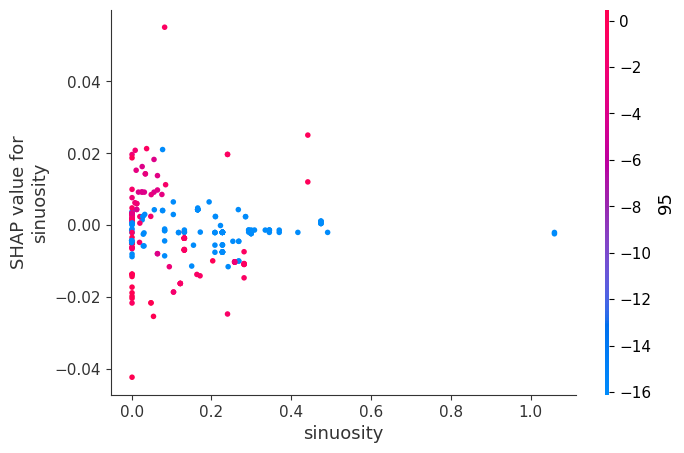

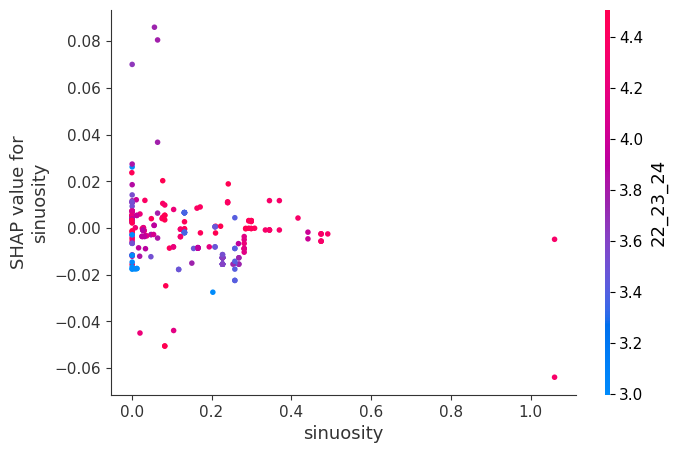

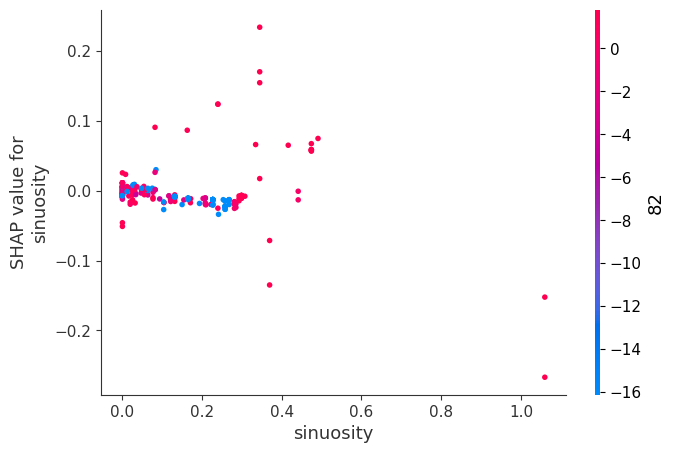

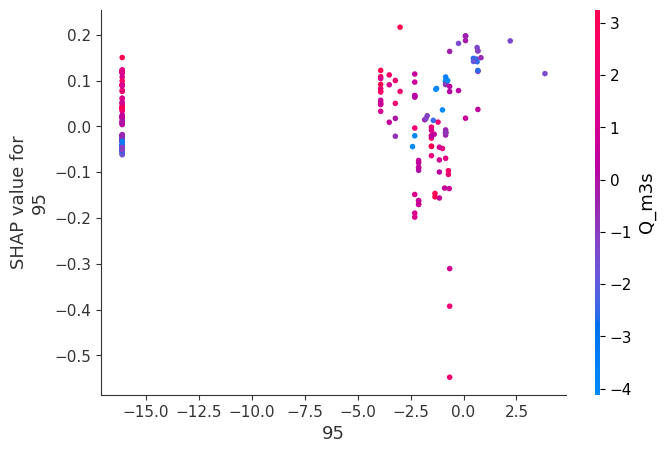

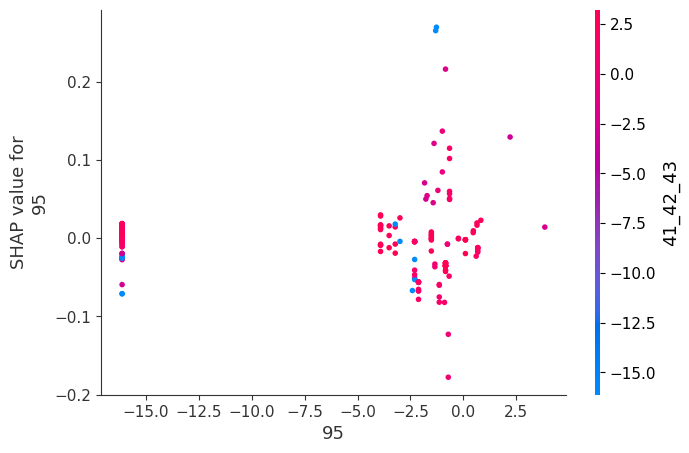

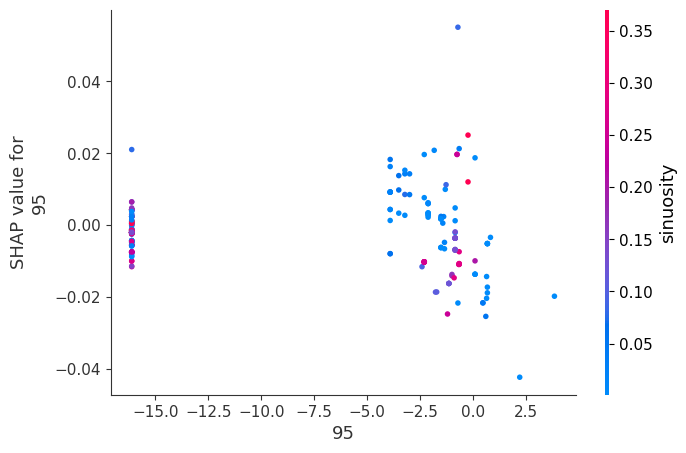

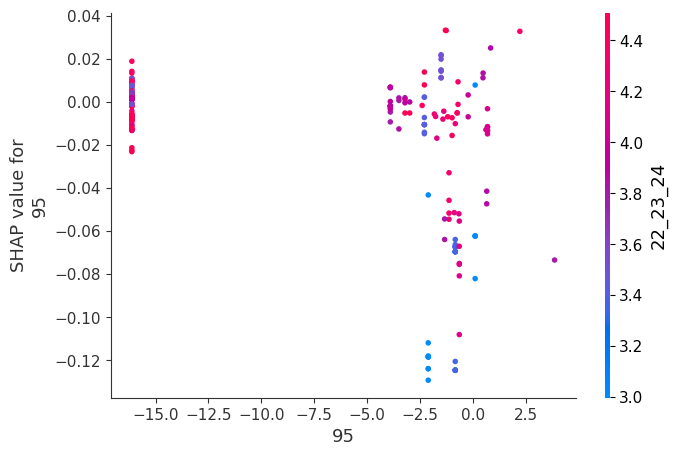

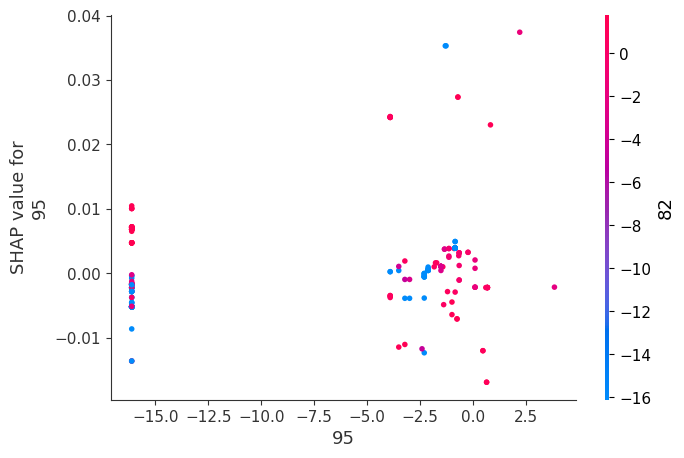

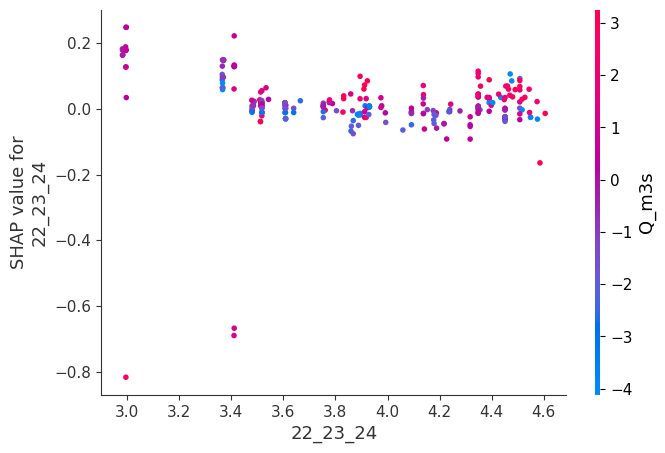

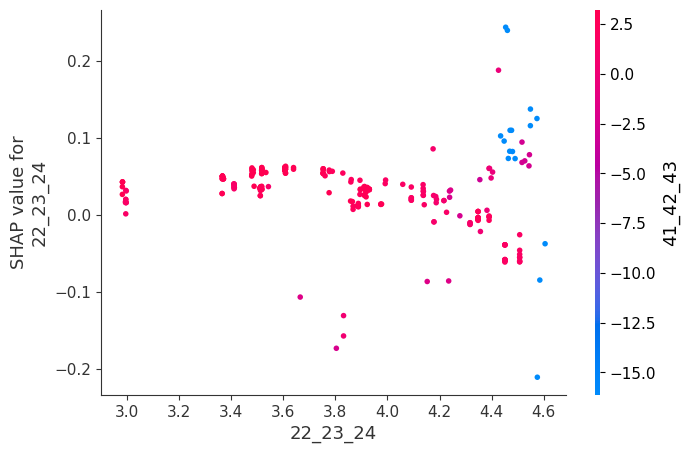

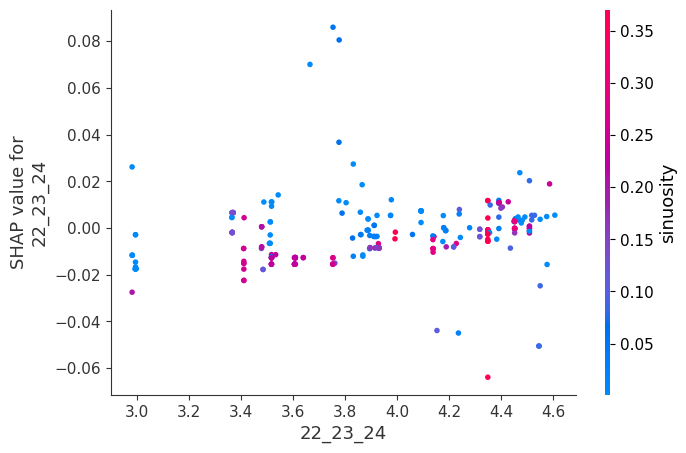

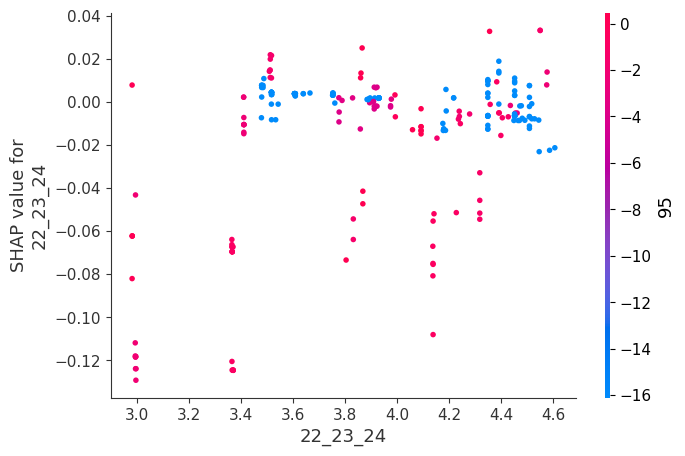

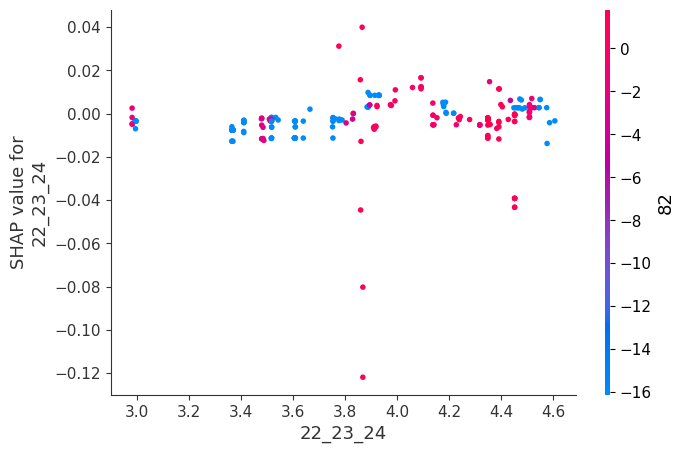

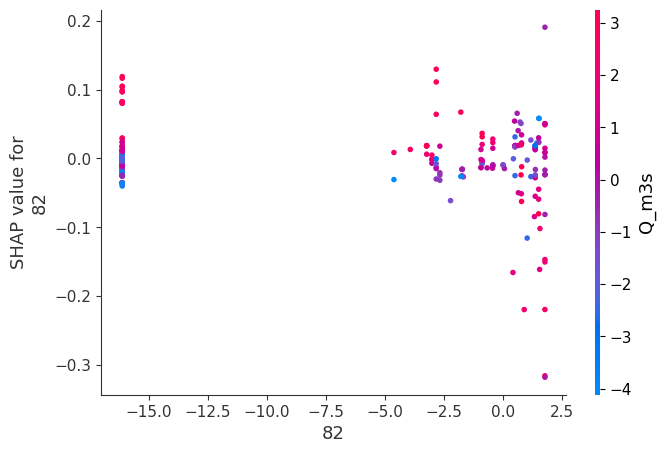

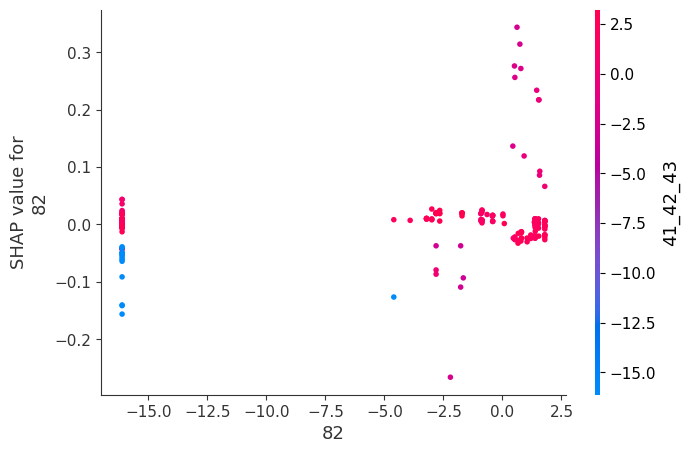

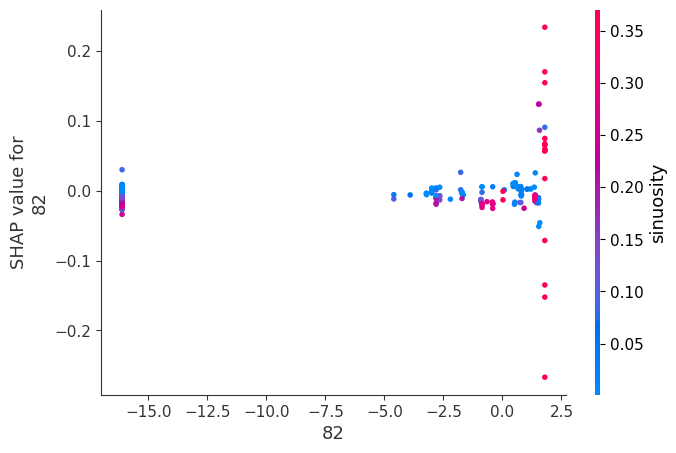

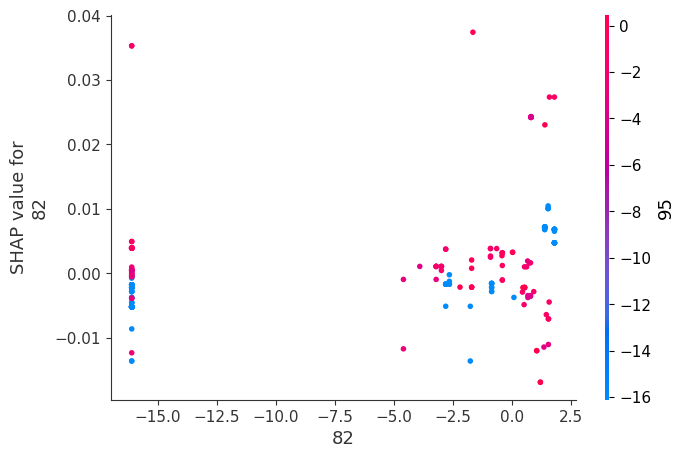

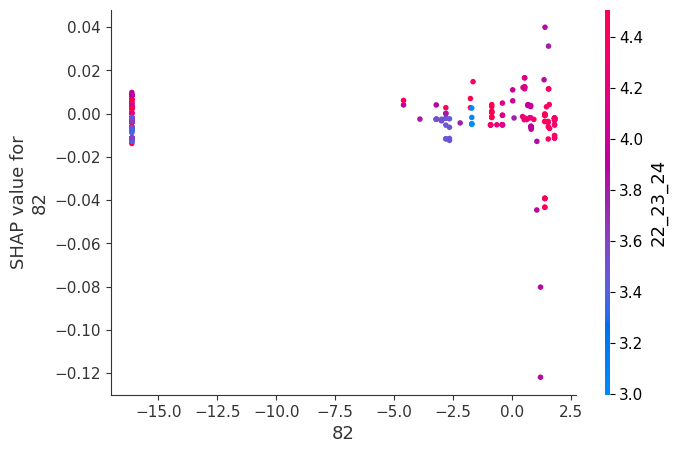

In [18]:
# Look at interaction plots

#Compute SHAP interaction values
tree_explainer = shap.TreeExplainer(reg)
interaction_values = tree_explainer.shap_interaction_values(X_test)

target_features = ["Q_m3s", "41_42_43", "sinuosity", "95", "22_23_24", "82"]

feature_names = X_test.columns.tolist()

for f1,f2 in product(target_features,target_features):
    if f1 == f2:
        continue
    i_f1 = feature_names.index(f1)
    i_f2 = feature_names.index(f2)


    # Extract interaction values for 'sinuosity'
    sinuosity_interactions = interaction_values[:, i_f1, i_f2]
    
    # Plot using raw SHAP values for 'sinuosity' and color by '41_42_43'
    shap.dependence_plot(
        i_f1,  # index of 'sinuosity'
        interaction_values[:, :, i_f2],  # SHAP values for all features interacting with '41_42_43'
        X_test,
        interaction_index=i_f2  # color by '41_42_43'
    )


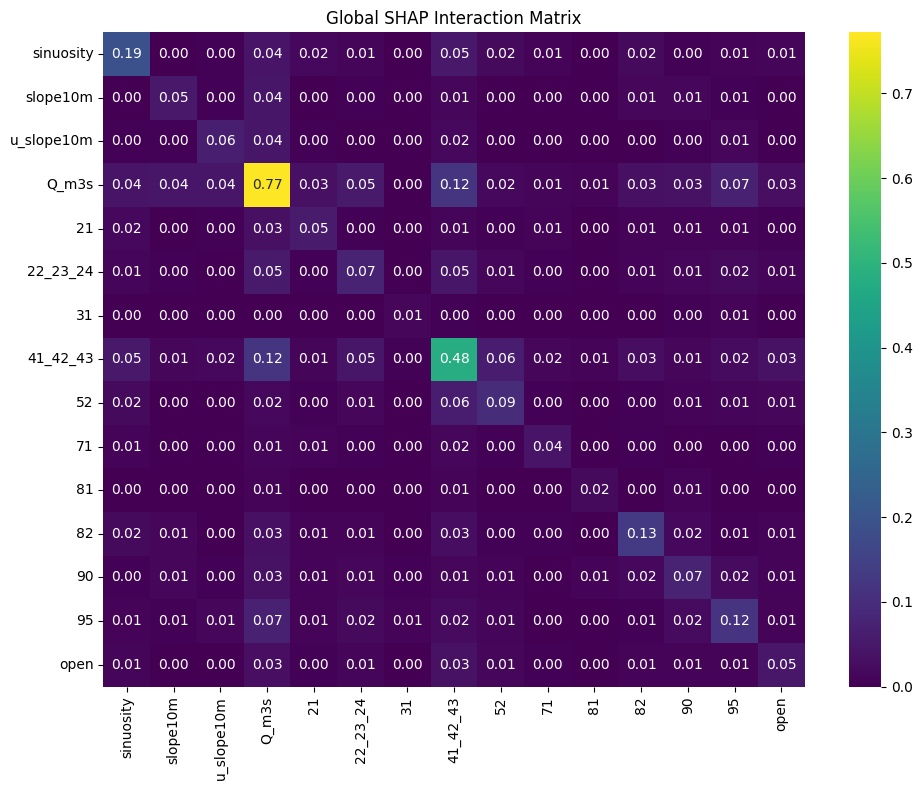

In [19]:

import shap
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have:
# - reg: your trained tree-based model
# - X_test: your test dataset as a DataFrame

# Create TreeExplainer and compute interaction values
explainer = shap.TreeExplainer(reg)

#X_int = X_test[target_features]
interaction_values = explainer.shap_interaction_values(X_test)

# Convert to numpy array and take absolute values
interaction_array = np.abs(np.array(interaction_values))

# Average across all samples to get global interaction matrix
interaction_matrix = interaction_array.mean(axis=0)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(interaction_matrix, xticklabels=X_test.columns, yticklabels=X_test.columns,
            cmap="viridis", annot=True, fmt=".2f")
plt.title("Global SHAP Interaction Matrix")
plt.tight_layout()
plt.show()


The r2 on the train set: 0.7172 and on the test set: 0.4099
The mse on the test set: 2.9192


/tmp/ipykernel_4415/1752818483.py:12: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k:" (-> color='k'). The keyword argument will take precedence.
  ax.loglog([1e1,1e4],[1e1,1e4],'k:',color="0.5")


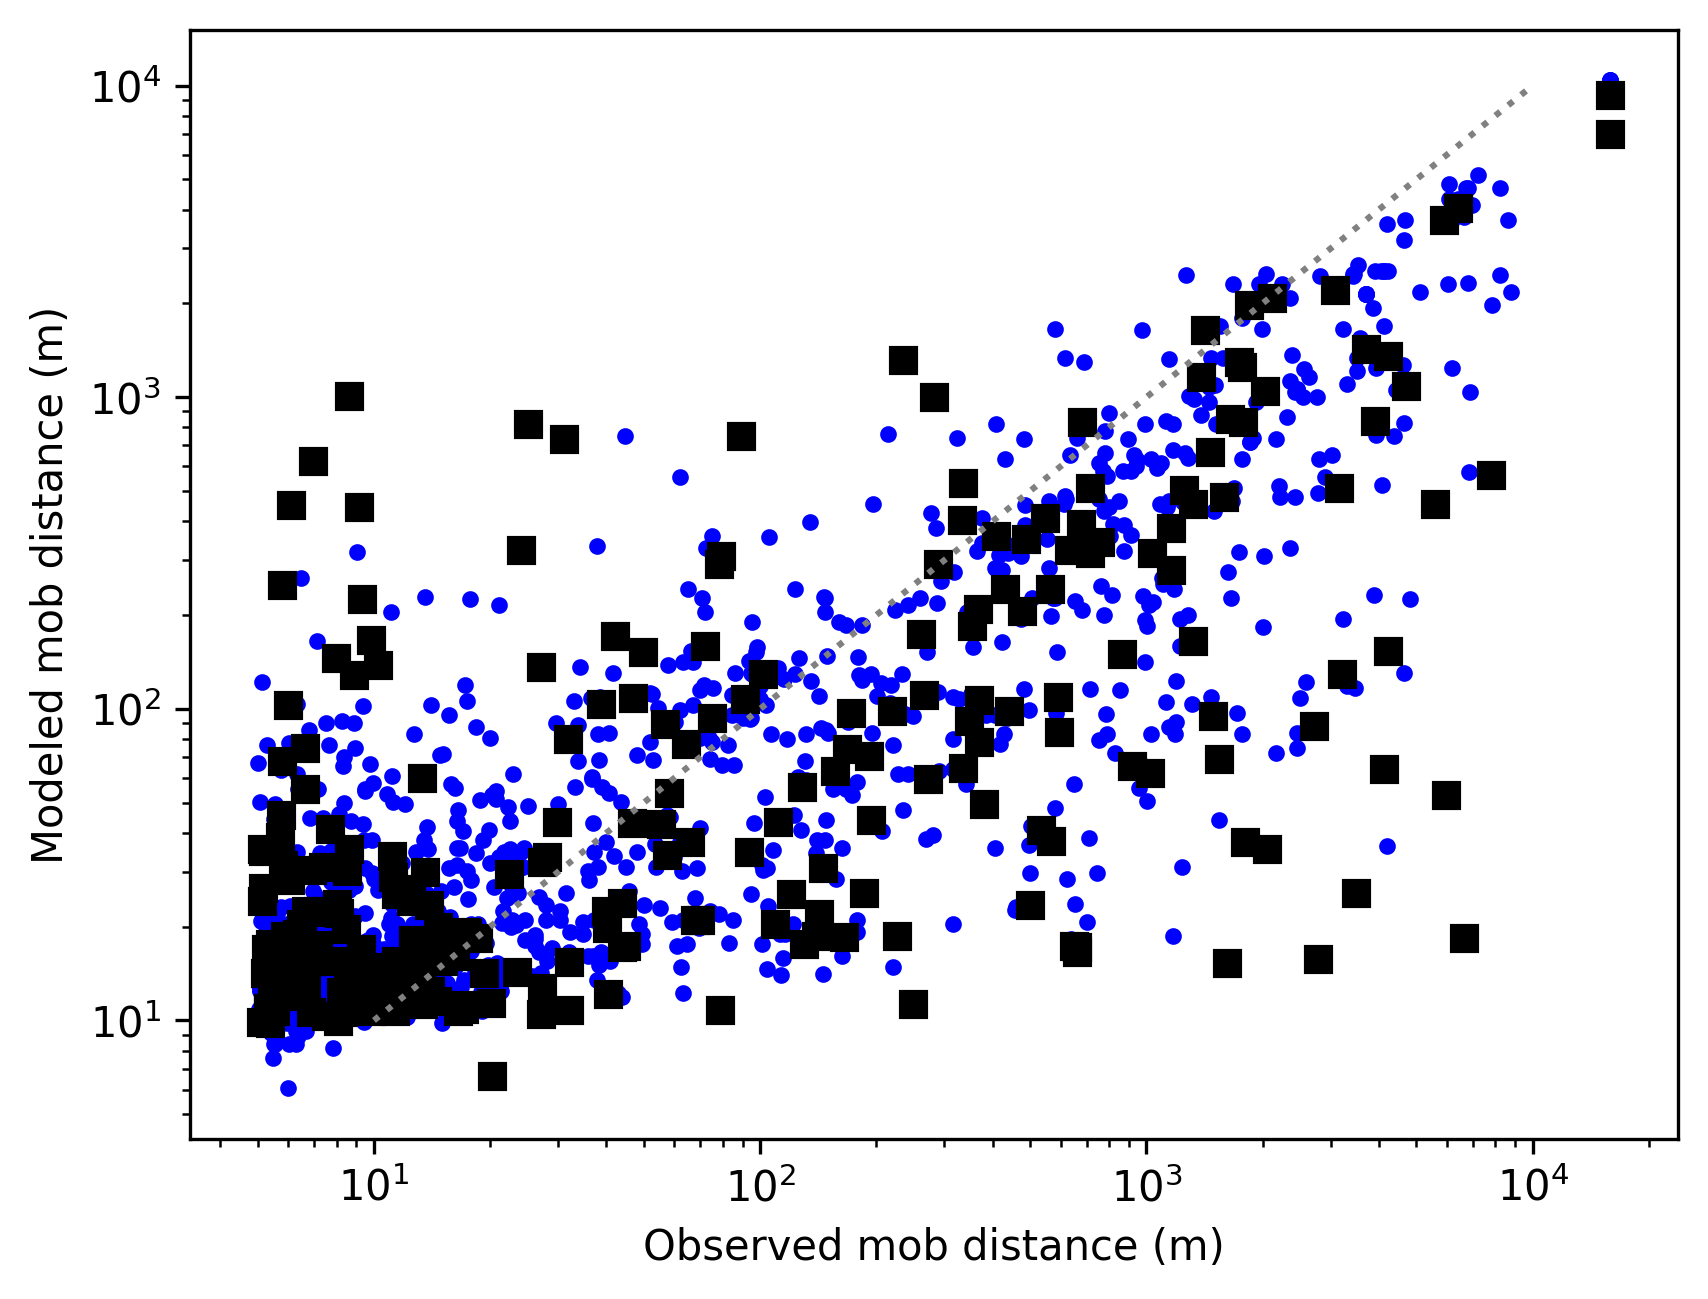

In [20]:
r2 = skmetrics.r2_score(y_test,reg.predict(X_test))
print("The r2 on the train set: {:0.4f} and on the test set: {:0.4f}".format(skmetrics.r2_score(y_train,reg.predict(X_train)),r2))
#mcc = skmetrics.matthews_corrcoef(y_test,reg.predict(X_test))
#print("The MCC on the train set: {:0.4f} and on the test set: {:0.4f}".format(skmetrics.matthews_corrcoef(y_train,reg.predict(X_train)),mcc))
mse = skmetrics.mean_squared_error(y_test,reg.predict(X_test))
print("The mse on the test set: {:0.4f}".format(mse))
fig,ax=plt.subplots(1,1,dpi=300)
ax.loglog(np.exp(y_train),np.exp(reg.predict(X_train)),'b.',label='Training')
ax.loglog(np.exp(y_test),np.exp(reg.predict(X_test)),'ks',label='Testing')
ax.set_xlabel("Observed mob distance (m)")
ax.set_ylabel("Modeled mob distance (m)")
ax.loglog([1e1,1e4],[1e1,1e4],'k:',color="0.5")

In [21]:
temp["41_42_43"]
temp["forest"] = temp["41_42_43"]
temp["urban"] = temp["22_23_24"]


In [22]:
temp["forest"]

watershed  Asset           dt                         site_no 
chicago    Clyde           2022-10-11 05:02:01-05:00  05535000    5.35
                           2022-10-30 11:11:29-05:00  05535000    5.35
           Caleb           2022-11-17 04:10:10-06:00  05535000    5.44
           Cassidy         2022-09-15 23:01:51-05:00  05535000    5.35
                           2022-09-16 17:17:14-05:00  05535000    5.35
                                                                  ... 
socal      Periwinkle_1_0  2024-01-20 18:10:49-08:00  11048600    0.08
           Periwinkle_1_1  2024-02-05 06:00:50-08:00  11048600    0.15
                           2024-02-07 09:58:50-08:00  11048600    0.14
                           2024-02-08 09:51:31-08:00  11048600    0.14
                           2024-02-09 13:58:32-08:00  11048600    0.14
Name: forest, Length: 1242, dtype: float64

In [23]:
print(temp.clip(lower=1e-7).reset_index(level=0)["Q_m3s"].min())

1e-07


Now we're going to do some multi-model selection and test all combinations of 5 factors that look like they could be the most important.


These include every combination of interactions regardless of whether the factor was in the main effects. Takes about 20 minutes to run em.

Now these limit the formulas to just those whose interaction terms are included in the main effects

In [24]:
Rormulas = []
N=0
for less in ["urban","sinuosity","schrub","wetland","crops"]:
    
    # Define predictors
    predictors = ['Q_m3s', 'forest',less ] #, 'urban'] #,'sinuosity']
    
    # Generate all non-empty combinations of main effects
    main_effect_combos = list(chain.from_iterable(
        combinations(predictors, r) for r in range(1, len(predictors) + 1)
    ))
    
    # Generate formulas with interaction terms only among variables present in main effects
    rormulas = set()
    transforms=lambda x: "sqrt" if x == "forest" else "log"
    
    for main_effects in main_effect_combos:
        main_str = ' + '.join([f'np.{transforms(var)}({var})' for var in main_effects])
        base_formula = f'np.log(len_m) ~ {main_str}'
    
        # Add interaction terms only among variables in main_effects
        interaction_terms = list(combinations(main_effects, 2))
        for r in range(len(interaction_terms) + 1):
            for interaction_combo in combinations(interaction_terms, r):
                interaction_str = ' + '.join([f'np.{transforms(i[0])}({i[0]}):np.{transforms(i[1])}({i[1]})' for i in interaction_combo])
                if interaction_str:
                    full_formula = f'{base_formula} + {interaction_str}'
                else:
                    full_formula = base_formula
                rormulas.add(full_formula)
    
    # Convert to sorted list and print summary
    rormulas = sorted(rormulas)
    print(f"Total unique formulas generated: {len(rormulas)}")
    N+=len(rormulas)
    Rormulas += [rormulas]
print(f"{N} total formulas")

Total unique formulas generated: 17
Total unique formulas generated: 17
Total unique formulas generated: 17
Total unique formulas generated: 17
Total unique formulas generated: 17
85 total formulas


In [25]:
Rormulas

[['np.log(len_m) ~ np.log(Q_m3s)',
  'np.log(len_m) ~ np.log(Q_m3s) + np.log(urban)',
  'np.log(len_m) ~ np.log(Q_m3s) + np.log(urban) + np.log(Q_m3s):np.log(urban)',
  'np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest)',
  'np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(Q_m3s):np.sqrt(forest)',
  'np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(urban)',
  'np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(urban) + np.log(Q_m3s):np.log(urban)',
  'np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(urban) + np.log(Q_m3s):np.log(urban) + np.sqrt(forest):np.log(urban)',
  'np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(urban) + np.log(Q_m3s):np.sqrt(forest)',
  'np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(urban) + np.log(Q_m3s):np.sqrt(forest) + np.log(Q_m3s):np.log(urban)',
  'np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(urban) + np.log(Q_m3s):np.sqrt(forest) + np.log(Q_m3s):np.log(urban) + np.sqrt(forest):np.log(urban)',
 

In [26]:
pd.set_option("display.precision", 2)
pd.set_option("display.width", 280)
pd.set_option("display.max_colwidth",220)

In [27]:
temp = lcdistclean.set_index("site_no",append=True).drop(columns=['Point_ID','level_0'])
temp = temp["len_m Q_m3s 41_42_43 22_23_24 sinuosity 52 95 82".split()]
temp = temp.rename(columns={"41_42_43":"forest","22_23_24":"urban","52":"schrub","95":"wetland","82":"crops"})
temp = temp.dropna()
temp = temp.clip(lower=1e-7)
miami = temp.xs("miami",level=0)
# Make clean  - less Miami and short events
clean = temp.drop("miami",level=0)
clean = clean[clean["len_m"] > 8]


for rormulas in Rormulas:
    AICs=[]
    BICs=[]
    r2adjs=[]
    jbs=[]
    for formula in rormulas:
        mod = smf.ols(formula,data=clean,missing='drop') #M=sm.robust.norms.HuberT())
        mod = mod.fit()
           
        #print(mod.summary())
        AICs.append(mod.aic)
        BICs.append(mod.bic)
        r2adjs.append(mod.rsquared_adj)
        jbs.append(sm.stats.stattools.jarque_bera(mod.resid)[1])
    regress_table = pd.DataFrame(index=range(len(rormulas)),data={"Formula":rormulas,"AIC":AICs,"BIC":BICs,"r2_adj":r2adjs,"Prob(Jarque-Bera)":jbs})
    display(regress_table.sort_values(by="r2_adj",ascending=False).head())


,Formula,AIC,BIC,r2_adj,Prob(Jarque-Bera)
10,np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(urban) + np.log(Q_m3s):np.sqrt(forest) + np.log(Q_m3s):np.log(urban) + np.sqrt(forest):np.log(urban),3333.12,3366.25,0.31,5.45e-04
7,np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(urban) + np.log(Q_m3s):np.log(urban) + np.sqrt(forest):np.log(urban),3332.45,3360.85,0.30,8.04e-04
9,np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(urban) + np.log(Q_m3s):np.sqrt(forest) + np.log(Q_m3s):np.log(urban),3345.96,3374.36,0.29,1.38e-04
6,np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(urban) + np.log(Q_m3s):np.log(urban),3346.73,3370.40,0.29,2.79e-04
11,np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(urban) + np.log(Q_m3s):np.sqrt(forest) + np.sqrt(forest):np.log(urban),3348.81,3377.21,0.29,5.75e-04


,Formula,AIC,BIC,r2_adj,Prob(Jarque-Bera)
10,np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(sinuosity) + np.log(Q_m3s):np.sqrt(forest) + np.log(Q_m3s):np.log(sinuosity) + np.sqrt(forest):np.log(sinuosity),3371.28,3404.41,0.27,7.29e-05
9,np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(sinuosity) + np.log(Q_m3s):np.sqrt(forest) + np.log(Q_m3s):np.log(sinuosity),3371.34,3399.74,0.27,1.01e-04
7,np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(sinuosity) + np.log(Q_m3s):np.log(sinuosity) + np.sqrt(forest):np.log(sinuosity),3373.45,3401.85,0.27,2.73e-05
6,np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(sinuosity) + np.log(Q_m3s):np.log(sinuosity),3373.90,3397.56,0.27,3.23e-05
4,np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(Q_m3s):np.sqrt(forest),3381.23,3400.17,0.26,2.44e-05


,Formula,AIC,BIC,r2_adj,Prob(Jarque-Bera)
7,np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(schrub) + np.log(Q_m3s):np.log(schrub) + np.sqrt(forest):np.log(schrub),3361.83,3390.23,0.28,3.99e-05
10,np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(schrub) + np.log(Q_m3s):np.sqrt(forest) + np.log(Q_m3s):np.log(schrub) + np.sqrt(forest):np.log(schrub),3363.16,3396.30,0.28,4.12e-05
12,np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(schrub) + np.sqrt(forest):np.log(schrub),3367.40,3391.06,0.27,2.24e-05
11,np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(schrub) + np.log(Q_m3s):np.sqrt(forest) + np.sqrt(forest):np.log(schrub),3369.29,3397.69,0.27,2.59e-05
9,np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(schrub) + np.log(Q_m3s):np.sqrt(forest) + np.log(Q_m3s):np.log(schrub),3370.10,3398.50,0.27,1.18e-05


,Formula,AIC,BIC,r2_adj,Prob(Jarque-Bera)
10,np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(wetland) + np.log(Q_m3s):np.sqrt(forest) + np.log(Q_m3s):np.log(wetland) + np.sqrt(forest):np.log(wetland),3346.39,3379.52,0.29,2.14e-05
7,np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(wetland) + np.log(Q_m3s):np.log(wetland) + np.sqrt(forest):np.log(wetland),3345.41,3373.81,0.29,9.07e-06
9,np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(wetland) + np.log(Q_m3s):np.sqrt(forest) + np.log(Q_m3s):np.log(wetland),3356.77,3385.17,0.28,2.54e-05
6,np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(wetland) + np.log(Q_m3s):np.log(wetland),3357.22,3380.89,0.28,6.41e-06
12,np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(wetland) + np.sqrt(forest):np.log(wetland),3376.47,3400.13,0.27,1.62e-05


,Formula,AIC,BIC,r2_adj,Prob(Jarque-Bera)
9,np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(crops) + np.log(Q_m3s):np.sqrt(forest) + np.log(Q_m3s):np.log(crops),3366.23,3394.63,0.28,1.84e-04
10,np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(crops) + np.log(Q_m3s):np.sqrt(forest) + np.log(Q_m3s):np.log(crops) + np.sqrt(forest):np.log(crops),3367.47,3400.60,0.28,2.24e-04
7,np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(crops) + np.log(Q_m3s):np.log(crops) + np.sqrt(forest):np.log(crops),3367.06,3395.46,0.28,1.50e-04
6,np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(crops) + np.log(Q_m3s):np.log(crops),3366.15,3389.81,0.28,9.94e-05
8,np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(crops) + np.log(Q_m3s):np.sqrt(forest),3366.25,3389.91,0.28,8.50e-05


Models containing urban cover are slightly more performant.  

In [28]:
temp = lcdistclean.set_index("site_no",append=True).drop(columns=['Point_ID','level_0'])
temp = temp["len_m Q_m3s 41_42_43 22_23_24 sinuosity 52 95 82".split()]
temp = temp.rename(columns={"41_42_43":"forest","22_23_24":"urban","52":"schrub","95":"wetland","82":"crops"})
temp["forest"] *= 0.01
temp["urban"] *= 0.01
temp = temp.dropna()
temp = temp.clip(lower=1e-7)
miami = temp.xs("miami",level=0)
# Make clean  - less Miami and short events
clean = temp.drop("miami",level=0)
clean = clean[clean["len_m"] > 8]
AICs=[]
BICs=[]
r2adjs=[]
jbs=[]
rormulas = Rormulas[0]  # These are the urban models

for formula in rormulas:
    robust_model = smf.rlm(formula,data=clean,missing='drop',M=sm.robust.norms.HuberT())
    #glm_model = smf.glm(formula,data=clean,missing='drop',family=sm.families.Gamma(link=sm.families.links.log()))
    robust_model = robust_model.fit()
    #glm_model = glm_model.fit()
    # wls flow
    #ols_model = smf.ols(formula,data=clean,missing='drop').fit()
    #wls_model = smf.wls(formula,data=clean,weights=1./(np.abs(ols_model.resid) + 1e-6),missing='drop').fit()
    
    
    # Assuming `robust_model` is your fitted RLM model
    # and `y` is your dependent variable (e.g., df['log_len_m'])
    
    # Number of observations and parameters
    n = robust_model.nobs
    k = robust_model.df_model + 1  # includes intercept
    #n = glm_model.nobs
    #k = glm_model.df_model + 1
    #n = wls_model.nobs
    #k = wls_model.df_model + 1
    
    # Residual sum of squares
    rss = np.sum(robust_model.resid ** 2)
    #rss = np.sum(glm_model.resid_response ** 2)
    #rss = np.sum(wls_model.resid ** 2)
    
    # AIC and BIC
    aic = n * np.log(rss / n) + 2 * k
    bic = n * np.log(rss / n) + k * np.log(n)
    
    # Adjusted R-squared
    y = np.log(clean['len_m'])
    y_mean = np.mean(y)
    tss = np.sum((y - y_mean) ** 2)
    r2 = 1 - rss / tss
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - k)
    
    # Jarque-Bera test
    jb_stat, jb_pvalue,_,_ = sm.stats.stattools.jarque_bera(robust_model.resid)
    #jb_stat, jb_pvalue,_,_ = sm.stats.stattools.jarque_bera(glm_model.resid_response)
    #jb_stat, jb_pvalue,_,_ = sm.stats.stattools.jarque_bera(wls_model.resid)
    
    # Print results
    #print(f"AIC: {aic:.2f}")
    #print(f"BIC: {bic:.2f}")
    #print(f"Adjusted R-squared: {r2_adj:.4f}")
    #print(f"Jarque-Bera Statistic: {jb_stat:.4f}, p-value: {jb_pvalue:.4g}")

    
    #print(mod.summary())
    AICs.append(aic)
    BICs.append(bic)
    r2adjs.append(r2_adj)
    jbs.append(jb_pvalue)
regress_table = pd.DataFrame(index=range(len(rormulas)),data={"Formula":rormulas,"AIC":AICs,"BIC":BICs,"r2_adj":r2adjs,"Prob(Jarque-Bera)":jbs})



In [29]:
regress_table["formula"] = regress_table["Formula"].apply(lambda x: x.replace("np.log",""))
display(regress_table.drop(columns="Formula").sort_values("Prob(Jarque-Bera)",ascending=False).head(10))
display(regress_table.drop(columns="Formula").sort_values("BIC",ascending=True))

,AIC,BIC,r2_adj,Prob(Jarque-Bera),formula
12,970.60,994.26,0.29,1.97e-02,(len_m) ~ (Q_m3s) + np.sqrt(forest) + (urban) + np.sqrt(forest):(urban)
11,968.02,996.42,0.29,1.08e-02,(len_m) ~ (Q_m3s) + np.sqrt(forest) + (urban) + (Q_m3s):np.sqrt(forest) + np.sqrt(forest):(urban)
7,950.92,979.32,0.30,5.72e-03,(len_m) ~ (Q_m3s) + np.sqrt(forest) + (urban) + (Q_m3s):(urban) + np.sqrt(forest):(urban)
10,951.55,984.68,0.30,4.31e-03,(len_m) ~ (Q_m3s) + np.sqrt(forest) + (urban) + (Q_m3s):np.sqrt(forest) + (Q_m3s):(urban) + np.sqrt(forest):(urban)
8,985.98,1009.65,0.27,1.73e-03,(len_m) ~ (Q_m3s) + np.sqrt(forest) + (urban) + (Q_m3s):np.sqrt(forest)
5,986.83,1005.77,0.27,1.71e-03,(len_m) ~ (Q_m3s) + np.sqrt(forest) + (urban)
6,965.20,988.86,0.29,1.60e-03,(len_m) ~ (Q_m3s) + np.sqrt(forest) + (urban) + (Q_m3s):(urban)
9,964.65,993.05,0.29,9.81e-04,(len_m) ~ (Q_m3s) + np.sqrt(forest) + (urban) + (Q_m3s):np.sqrt(forest) + (Q_m3s):(urban)
4,999.31,1018.25,0.26,4.16e-04,(len_m) ~ (Q_m3s) + np.sqrt(forest) + (Q_m3s):np.sqrt(forest)
3,998.85,1013.05,0.26,3.37e-04,(len_m) ~ (Q_m3s) + np.sqrt(forest)


,AIC,BIC,r2_adj,Prob(Jarque-Bera),formula
7,950.92,979.32,0.30,5.72e-03,(len_m) ~ (Q_m3s) + np.sqrt(forest) + (urban) + (Q_m3s):(urban) + np.sqrt(forest):(urban)
10,951.55,984.68,0.30,4.31e-03,(len_m) ~ (Q_m3s) + np.sqrt(forest) + (urban) + (Q_m3s):np.sqrt(forest) + (Q_m3s):(urban) + np.sqrt(forest):(urban)
6,965.20,988.86,0.29,1.60e-03,(len_m) ~ (Q_m3s) + np.sqrt(forest) + (urban) + (Q_m3s):(urban)
9,964.65,993.05,0.29,9.81e-04,(len_m) ~ (Q_m3s) + np.sqrt(forest) + (urban) + (Q_m3s):np.sqrt(forest) + (Q_m3s):(urban)
12,970.60,994.26,0.29,1.97e-02,(len_m) ~ (Q_m3s) + np.sqrt(forest) + (urban) + np.sqrt(forest):(urban)
11,968.02,996.42,0.29,1.08e-02,(len_m) ~ (Q_m3s) + np.sqrt(forest) + (urban) + (Q_m3s):np.sqrt(forest) + np.sqrt(forest):(urban)
5,986.83,1005.77,0.27,1.71e-03,(len_m) ~ (Q_m3s) + np.sqrt(forest) + (urban)
8,985.98,1009.65,0.27,1.73e-03,(len_m) ~ (Q_m3s) + np.sqrt(forest) + (urban) + (Q_m3s):np.sqrt(forest)
3,998.85,1013.05,0.26,3.37e-04,(len_m) ~ (Q_m3s) + np.sqrt(forest)
4,999.31,1018.25,0.26,4.16e-04,(len_m) ~ (Q_m3s) + np.sqrt(forest) + (Q_m3s):np.sqrt(forest)


In [30]:
from patsy import dmatrices

In [31]:
model = smf.ols("urban ~ forest",data=clean,missing='drop') #M=sm.robust.norms.HuberT())
    
fit = model.fit()
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:                  urban   R-squared:                       0.332
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     416.1
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           2.06e-75
Time:                        14:35:55   Log-Likelihood:                 282.11
No. Observations:                 840   AIC:                            -560.2
Df Residuals:                     838   BIC:                            -550.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6925      0.010     66.862      0.0

In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

np.log(len_m) ~ np.log(Q_m3s) + np.sqrt(forest) + np.log(urban) + np.sqrt(forest):np.log(urban)
AIC: 970.6, BIC: 994.3, r2adj: 0.286, P(jb): 0.020
(840, 5)
VIFs: 
[('Intercept', 22.20854446238042), ('np.log(Q_m3s)', 1.0430361721758779), ('np.sqrt(forest)', 5.493430249537214), ('np.log(urban)', 7.163132577132308), ('np.sqrt(forest):np.log(urban)', 16.076603420108682)]
                    Robust linear Model Regression Results                    
Dep. Variable:          np.log(len_m)   No. Observations:                  840
Model:                            RLM   Df Residuals:                      835
Method:                          IRLS   Df Model:                            4
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Fri, 10 Apr 2026                                        

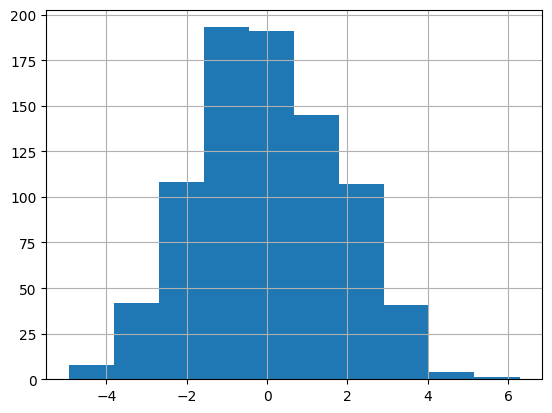

In [33]:
best_idx = 12
formula = rormulas[best_idx]
print(formula)
print("AIC: {:0.1f}, BIC: {:0.1f}, r2adj: {:0.3f}, P(jb): {:0.3f}".format(AICs[best_idx], BICs[best_idx], r2adjs[best_idx], jbs[best_idx]))

mod = smf.rlm(formula,data=clean,missing='drop',M=sm.robust.norms.HuberT())
#glm_model = smf.glm(formula,data=clean,missing='drop',family=sm.families.Gamma(link=sm.families.links.log()))
#ols_model = smf.ols(formula,data=clean,missing='drop').fit()
#wls_model = smf.wls(formula,data=clean,missing='drop',weights=1./(np.abs(ols_model.resid) + 1e-6))


# Create design matrices
y, X = dmatrices(formula, data=clean, return_type='dataframe')
print(X.shape)
print("VIFs: ")
print([(X.iloc[:,i].name,vif(X,i)) for i in range(X.shape[1]) ])

mod = mod.fit()
mod.resid.hist()
print(mod.summary())

#glm_model = glm_model.fit()
#wls_model = wls_model.fit()
#print(dir(glm_model))
#wls_model.resid.hist().plot()

In [34]:
mod.wald_test("np.log(Q_m3s) = 0")

/home/shan/.pyenv/versions/3.11.9/lib/python3.11/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.ContrastResults'>
<Wald test (chi2): statistic=[[194.5022898]], p-value=3.3085466360534733e-44, df_denom=1>

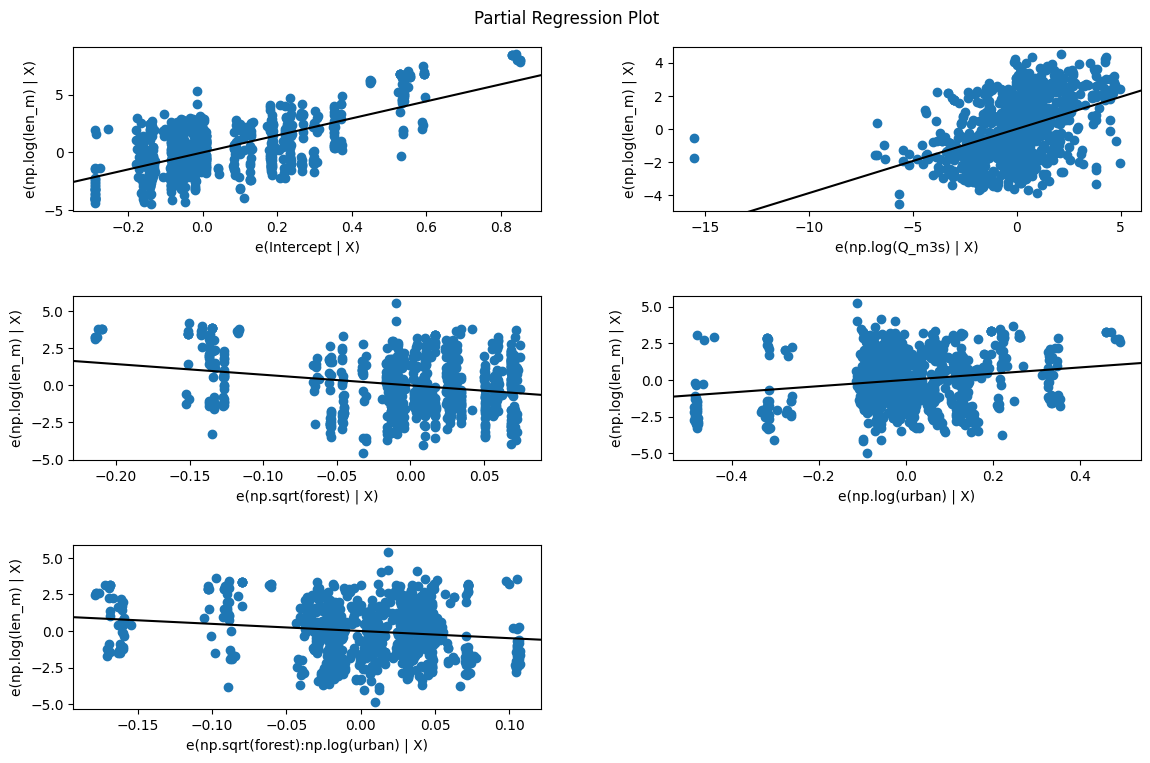

In [35]:
fig = sm.graphics.plot_partregress_grid(mod)
fig.tight_layout(pad=0.5)
fig.set_size_inches((12,8))

In [36]:
print(mod.sresid)

watershed  Asset           dt                         site_no 
chicago    Caleb           2022-11-17 04:10:10-06:00  05535000   -1.54
           Cassidy         2022-10-26 11:10:08-05:00  05535000    1.15
                           2022-10-29 17:09:55-05:00  05535000   -0.13
                           2022-10-31 05:00:39-05:00  05535000    0.06
                           2022-10-31 17:22:35-05:00  05535000   -1.03
                                                                  ... 
socal      Periwinkle_1_0  2024-01-20 18:10:49-08:00  11048600    1.24
           Periwinkle_1_1  2024-02-05 06:00:50-08:00  11048600    0.48
                           2024-02-07 09:58:50-08:00  11048600   -1.12
                           2024-02-08 09:51:31-08:00  11048600   -1.27
                           2024-02-09 13:58:32-08:00  11048600   -1.13
Length: 840, dtype: float64


In [37]:
from scipy import stats
# Residuals from robust regression
#residuals = glm_model.resid_response
#residuals = wls_model.resid
residuals = mod.resid

# Candidate distributions
candidates = [stats.norm, stats.t, stats.laplace, stats.cauchy, stats.skewnorm,stats.lognorm]

# Fit and test each distribution
for dist in candidates:
    params = dist.fit(residuals)
    ks_stat, ks_pvalue = stats.kstest(residuals, dist.name, args=params)
    print(f"Distribution: {dist.name}")
    print(f"Parameters: {params}")
    print(f"KS Statistic: {ks_stat:.4f}, p-value: {ks_pvalue:.4g}\n")


Distribution: norm
Parameters: (0.012353653833794538, 1.7713809816131474)
KS Statistic: 0.0329, p-value: 0.3162

Distribution: t
Parameters: (146686566392.13803, 0.012353385080848354, 1.7713804057325935)
KS Statistic: 0.0329, p-value: 0.3162

Distribution: laplace
Parameters: (-0.04640217529044355, 1.4530638442306614)
KS Statistic: 0.0636, p-value: 0.002148

Distribution: cauchy
Parameters: (-0.07454678483349958, 1.1530827496099318)
KS Statistic: 0.0915, p-value: 1.445e-06

Distribution: skewnorm
Parameters: (0.8251630817764036, -1.0327171915322413, 2.056690378736577)
KS Statistic: 0.0307, p-value: 0.401

Distribution: lognorm
Parameters: (0.04494561853103404, -39.392302323731016, 39.36472819594598)
KS Statistic: 0.0301, p-value: 0.4228



/home/shan/.pyenv/versions/3.11.9/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:6547: RuntimeWarning: invalid value encountered in log
  lndata = np.log(data - loc)


{'sfbay': (0.2235294117647059, 0.23137254901960785, 0.4745098039215686, 1.0), 'socal': (0.4196078431372549, 0.43137254901960786, 0.8117647058823529, 1.0), 'chicago': (0.5490196078431373, 0.6352941176470588, 0.3215686274509804, 1.0), 'don': (0.5490196078431373, 0.42745098039215684, 0.19215686274509805, 1.0), 'anacostia': (0.9058823529411765, 0.796078431372549, 0.5803921568627451, 1.0), 'ipswich': (0.8392156862745098, 0.3803921568627451, 0.4196078431372549, 1.0), 'miami': (0.6470588235294118, 0.3176470588235294, 0.5803921568627451, 1.0)}
Walnut
S.California
N.Chicago
Don
Anacostia
Ipswich
0.05    1.50e-03
0.50    1.04e-01
0.95    2.52e-01
Name: forest, dtype: float64
0.5    0.49
Name: urban, dtype: float64
[3.80335222e+00 6.35393678e+03 8.59379777e+03 1.02541206e+04
 1.16232444e+04]
[1.37382566e+00 2.29513358e+03 3.10420366e+03 3.70393622e+03
 4.19848347e+03]
[7.21001499e-01 1.20451583e+03 1.62912628e+03 1.94387370e+03
 2.20341850e+03]


/tmp/ipykernel_4415/265691902.py:72: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred = mod.params[0]+mod.params[1]*Xq[0,:]+mod.params[2]*Xq[1,:]+mod.params[3]*Xq[2,:]+mod.params[4]*Xq[3,:]
/tmp/ipykernel_4415/265691902.py:87: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=0.05)


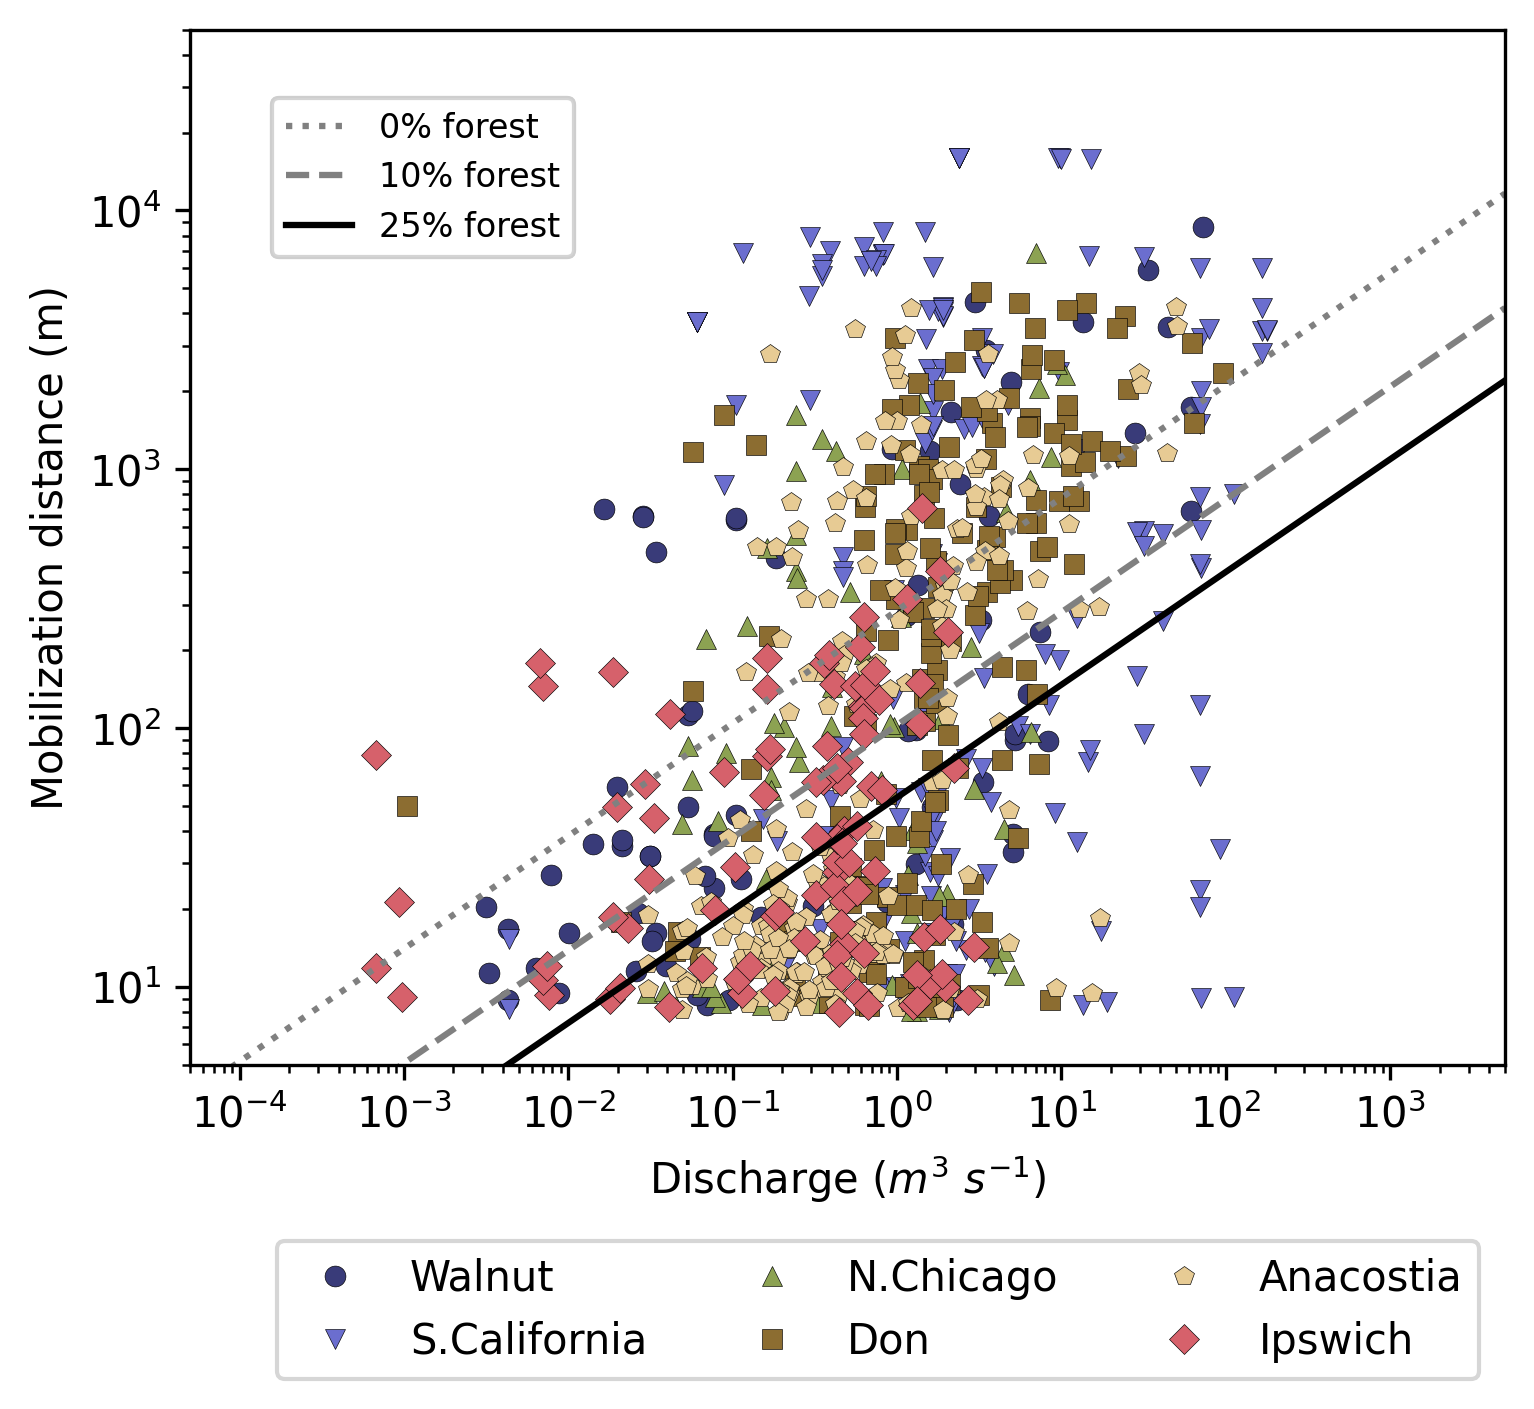

In [38]:
def get_color(uniques,cmap="tab20b"):
    
    cm=mpl.colormaps[cmap]
    uniqdict=dict((unique,cm(float(j)/len(uniques))) for unique,j in zip(uniques,range(len(uniques))))
    return uniqdict

def get_marker(uniques):
    markers=["o","v","^","s","p","D","*"]
    uniqdict=dict((unique,markers[j]) for unique,j in zip(uniques,range(len(uniques))))
    return uniqdict

dist_cutoff = 8

temp = lcdistclean.set_index("site_no",append=True).drop(columns=['Point_ID','level_0'])
temp = temp["len_m Q_m3s 41_42_43 22_23_24 sinuosity 52 95 82".split()]
temp = temp.rename(columns={"41_42_43":"forest","22_23_24":"urban","52":"schrub","95":"wetland","82":"crops"})
temp = temp.dropna()
temp["forest"] *= 0.01
temp["urban"] *= 0.01
temp = temp.clip(lower=1e-7)
miami = temp.xs("miami",level=0)
# Make clean  - less Miami and short events
clean = temp.drop("miami",level=0)
lows = clean[clean["len_m"] <= dist_cutoff]
clean = clean[clean["len_m"] > dist_cutoff]

wseds = ['sfbay', 'socal', 'chicago','don', 'anacostia',  'ipswich', 'miami']

color_dict=get_color(wseds)
marker_dict=get_marker(wseds)
print(color_dict)
fig,axs=plt.subplots(1,1,dpi=300,sharey="row",figsize=(5,4),constrained_layout=True) 
axs=[axs]
for j,ax in enumerate(axs):

    def get_plabel(x):
        return ws_names[x]
    for site in wseds:
        if site == "miami":
            continue
        dist = clean.xs(site,level=0)

        print(get_plabel(site))
        dist.plot(ax=ax,x="Q_m3s",y="len_m",marker=marker_dict[site],c=color_dict[site],mec='k',ms=5,mew=0.15,ls="none",logx=False,logy=False,label=get_plabel(site))
        
    (lo,hi)=ax.get_xlim()
    lo,hi = 5e-5,5e3
    X=np.log(np.linspace(lo,hi,5))
    (yo,yi)=ax.get_ylim()
    yo,yi = 5e0,5e4    
    if j==1:
        miami.plot(ax=ax,x="Q_m3s",y="len_m",marker='x',c=color_dict["miami"],ls="none",logx=False,logy=False,ms=5,label="Miami")
        ax.get_legend().remove()
        for site,dist in lows.groupby(level=0):
            dist.plot(ax=ax,x="Q_m3s",y="len_m",marker='x',c=color_dict[site],ls="none",logx=False,logy=False,ms=5,legend=False)
    else:
        ax.get_legend().remove()
        (handles,labels) = ax.get_legend_handles_labels()

        qs_1 = clean["forest"].quantile([0.05,0.5,0.95]).clip(lower=1e-9)
        qs_2 = clean["urban"].quantile([0.5])
        ps = ["{:0.0f}% forest".format(100.*q) for q in qs_1]
        lss = [":","--","-"]
        lcs = ["0.5","0.5","k"]
        print(qs_1)
        print(qs_2)
        for k,q in enumerate(qs_1):
            Xq = np.stack((X,(q**.5)*np.ones_like(X),np.log(qs_2.values)*np.ones_like(X),(q**.5)*np.log(qs_2.values)*np.ones_like(X)))
            #print(Xq)
            if len(mod.params) > 2:
                
                pred = mod.params[0]+mod.params[1]*Xq[0,:]+mod.params[2]*Xq[1,:]+mod.params[3]*Xq[2,:]+mod.params[4]*Xq[3,:]
            else:
                pred = mod.params[0]+mod.params[1]*Xq[0,:]
            print(np.exp(pred))
            
            ax.plot(np.exp(X),np.exp(pred),ls=lss[k],color=lcs[k],label=ps[k])
    
    ax.set_xlim((lo,hi))
    ax.set_ylim((yo,yi))
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel("Mobilization distance (m)")
    ax.set_xlabel("Discharge ($m^3\ s^{-1}$)")
    #ax.text(0.025,0.95,"ab"[j]+")",transform=ax.transAxes)

fig.subplots_adjust(wspace=0.05)
legend1 = axs[0].legend(handles,labels,bbox_to_anchor=[0.05,-0.30,0.3,0.15],ncol=3,loc=2)
axs[0].add_artist(legend1)

lines = [mpl.lines.Line2D([],[],color=lc,ls=ls,label=p) for p,ls,lc in zip(ps,lss,lcs)]
legend2 = axs[0].legend(lines,ps,bbox_to_anchor=[0.05,0.85,0.4,0.1],loc=2,fontsize=8)
axs[0].add_artist(legend2)

{'sfbay': (0.2, 0.2, 0.6, 1.0), 'socal': (0.011764705882352955, 0.5764705882352941, 0.9764705882352941, 1.0), 'chicago': (0.1450980392156863, 0.8290196078431373, 0.42901960784313725, 1.0), 'don': (0.7098039215686275, 0.9419607843137255, 0.5419607843137255, 1.0), 'anacostia': (0.8549019607843137, 0.8142745098039216, 0.5216470588235294, 1.0), 'ipswich': (0.5725490196078431, 0.45286274509803925, 0.36917647058823533, 1.0), 'miami': (0.7176470588235294, 0.6385882352941177, 0.6216470588235294, 1.0)}
Walnut
S.California
N.Chicago
Don
Anacostia
Ipswich


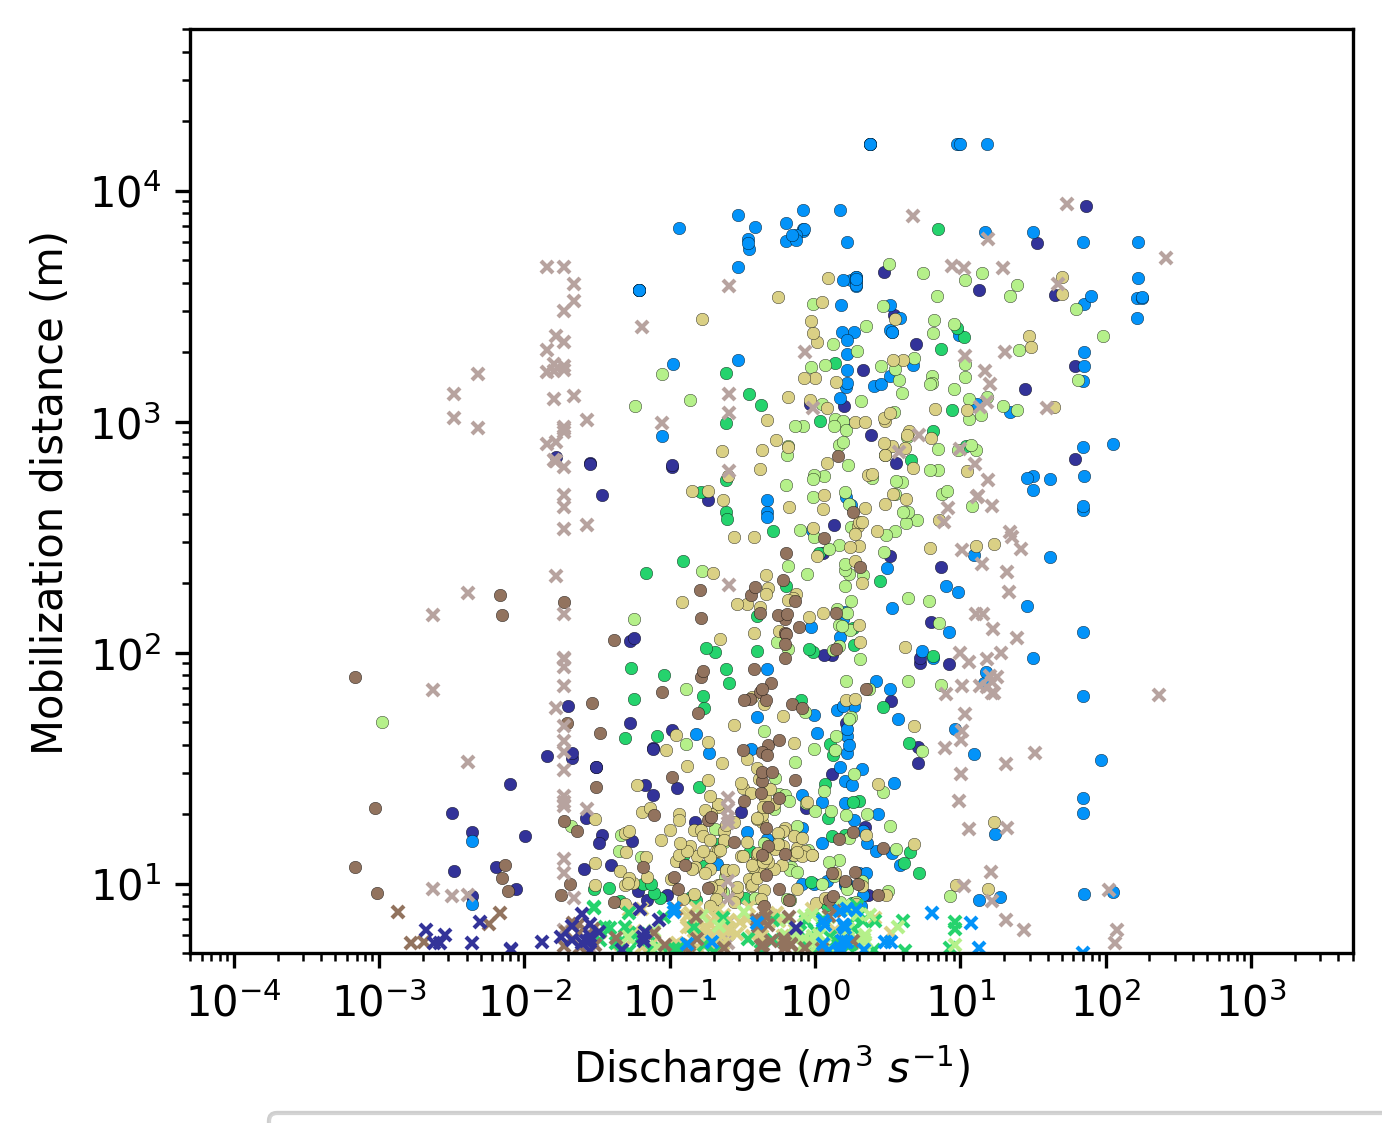

In [39]:
def get_color(uniques,cmap="terrain"):   
    cm=mpl.colormaps[cmap]
    uniqdict=dict((unique,cm(float(j)/len(uniques))) for unique,j in zip(uniques,range(len(uniques))))
    return uniqdict

dist_cutoff = 8

temp = lcdistclean.set_index("site_no",append=True).drop(columns=['Point_ID','level_0'])
temp = temp["len_m Q_m3s 41_42_43 22_23_24 sinuosity 52 95 82".split()]
temp = temp.rename(columns={"41_42_43":"forest","22_23_24":"urban","52":"schrub","95":"wetland","82":"crops"})
temp = temp.dropna()
temp["forest"] *= 0.01
temp["urban"] *= 0.01
temp = temp.clip(lower=1e-7)
miami = temp.xs("miami",level=0)
# Make clean  - less Miami and short events
clean = temp.drop("miami",level=0)
lows = clean[clean["len_m"] <= dist_cutoff]
clean = clean[clean["len_m"] > dist_cutoff]

wseds = ['sfbay', 'socal', 'chicago','don', 'anacostia',  'ipswich', 'miami']

color_dict=get_color(wseds)
print(color_dict)
fig,axs=plt.subplots(1,1,dpi=300,sharey="row",figsize=(5,4)) 
axs=[axs]
for j,ax in enumerate(axs):

    def get_plabel(x):
        return ws_names[x]
    for site in wseds:
        if site == "miami":
            continue
        dist = clean.xs(site,level=0)

        print(get_plabel(site))
        dist.plot(ax=ax,x="Q_m3s",y="len_m",marker=".",c=color_dict[site],mec='k',mew=0.09,ls="none",logx=False,logy=False,label=get_plabel(site))
        
    (lo,hi)=ax.get_xlim()
    lo,hi = 5e-5,5e3
    X=np.log(np.linspace(lo,hi,5))
    (yo,yi)=ax.get_ylim()
    yo,yi = 5e0,5e4    
    if j==0:
        miami.plot(ax=ax,x="Q_m3s",y="len_m",marker='x',c=color_dict["miami"],ls="none",logx=False,logy=False,ms=3,label="Miami")
        (handles,labels) = ax.get_legend_handles_labels() #(bbox_to_anchor=[0.05,1.01,0.9,0.15],ncol=4)
        ax.get_legend().remove()
        for site,dist in lows.groupby(level=0):
            dist.plot(ax=ax,x="Q_m3s",y="len_m",marker='x',c=color_dict[site],ls="none",logx=False,logy=False,ms=3,legend=False)    
    ax.set_xlim((lo,hi))
    ax.set_ylim((yo,yi))
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel("Mobilization distance (m)")
    ax.set_xlabel("Discharge ($m^3\ s^{-1}$)")
    #ax.text(0.025,0.95,"ab"[j]+")",transform=ax.transAxes)

fig.subplots_adjust(wspace=0.05)
legend1 = axs[0].legend(handles,labels,bbox_to_anchor=[0.05,-0.30,0.3,0.15],ncol=3,loc=2)
axs[0].add_artist(legend1)

S21
S22
S27
S30C


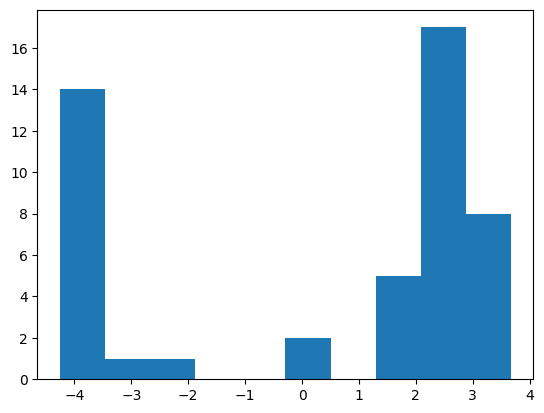

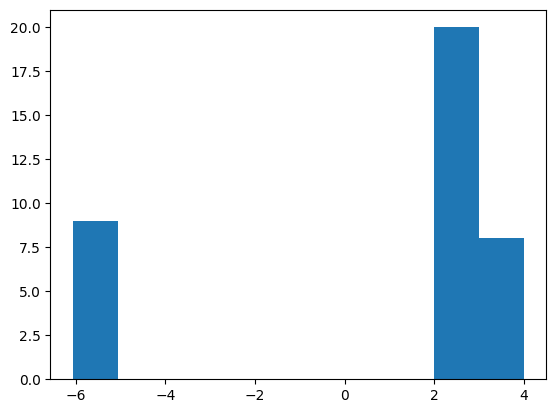

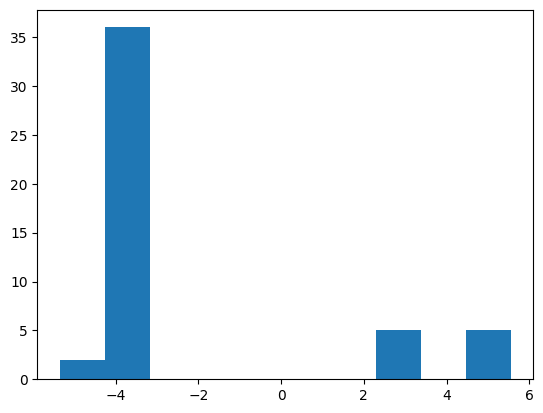

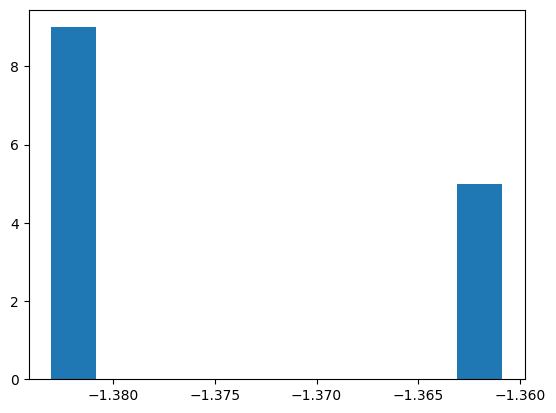

In [40]:
for site,this in miami.groupby('site_no'):
    print(site)
    fig,ax=plt.subplots(1,1)
    ax.hist(np.log(this["Q_m3s"]))